<a href="https://colab.research.google.com/github/drakopablo/eml_k_bandit_grupo17/blob/yolanda/egreedy_YOL2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
!git clone -b Yolanda https://github.com/USUARIO/eml_k_bandit_grupo17.git

Cloning into 'eml_k_bandit_grupo17'...
fatal: could not read Username for 'https://github.com': No such device or address


In [2]:
%cd /content/eml_k_bandit_grupo17

[Errno 2] No such file or directory: '/content/eml_k_bandit_grupo17'
/content


In [3]:
!ls

sample_data


In [5]:
from arms.armnormal import ArmNormal
from algorithms.epsilon_greedy import EpsilonGreedy
import numpy as np

from arms.armnormal import ArmNormal
from arms.bandit import Bandit
from algorithms.epsilon_greedy import EpsilonGreedy

from plotting.plotting import plot_average_rewards, plot_optimal_selections
from plotting.sutton import plot_reward_distributions
from plotting.regacu import plot_cumulative_regret


# =====================================================
# SEMILLA
# =====================================================

SEED = 42
np.random.seed(SEED)

import numpy as np

from arms.armbernoulli import ArmBernoulli
from arms.bandit import Bandit
from algorithms.epsilon_greedy import EpsilonGreedy

from plotting.plotting import plot_average_rewards, plot_optimal_selections
from plotting.sutton import plot_reward_distributions
from plotting.regacu import plot_cumulative_regret


# =====================================================
# SEMILLA
# =====================================================

SEED = 42
np.random.seed(SEED)

import numpy as np

from arms.armbinomial import ArmBinomial
from arms.bandit import Bandit
from algorithms.epsilon_greedy import EpsilonGreedy

from plotting.plotting import plot_average_rewards, plot_optimal_selections
from plotting.sutton import plot_reward_distributions
from plotting.regacu import plot_cumulative_regret


# =====================================================
# SEMILLA
# =====================================================

SEED = 42
np.random.seed(SEED)

ModuleNotFoundError: No module named 'arms'

# **ArmNormal**


k = 10, 20, 100

ε = 0, 0.01, 0.1


===== k = 10 =====


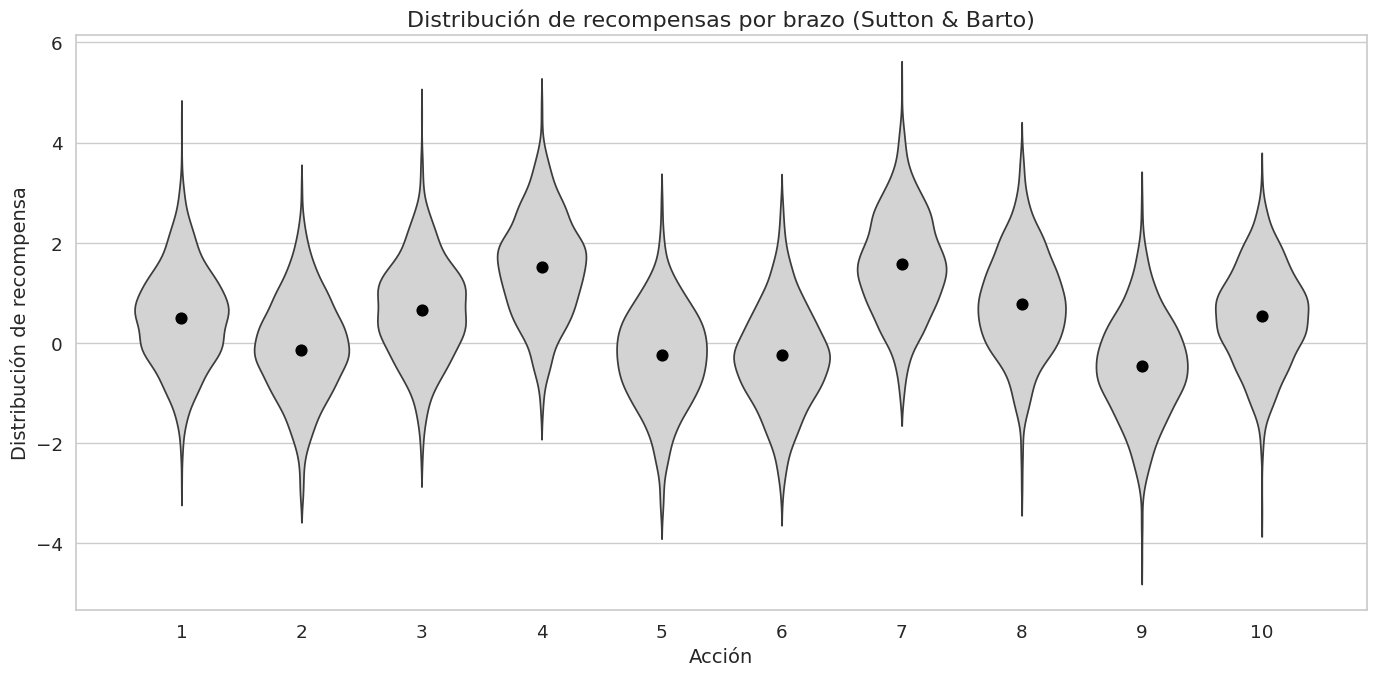

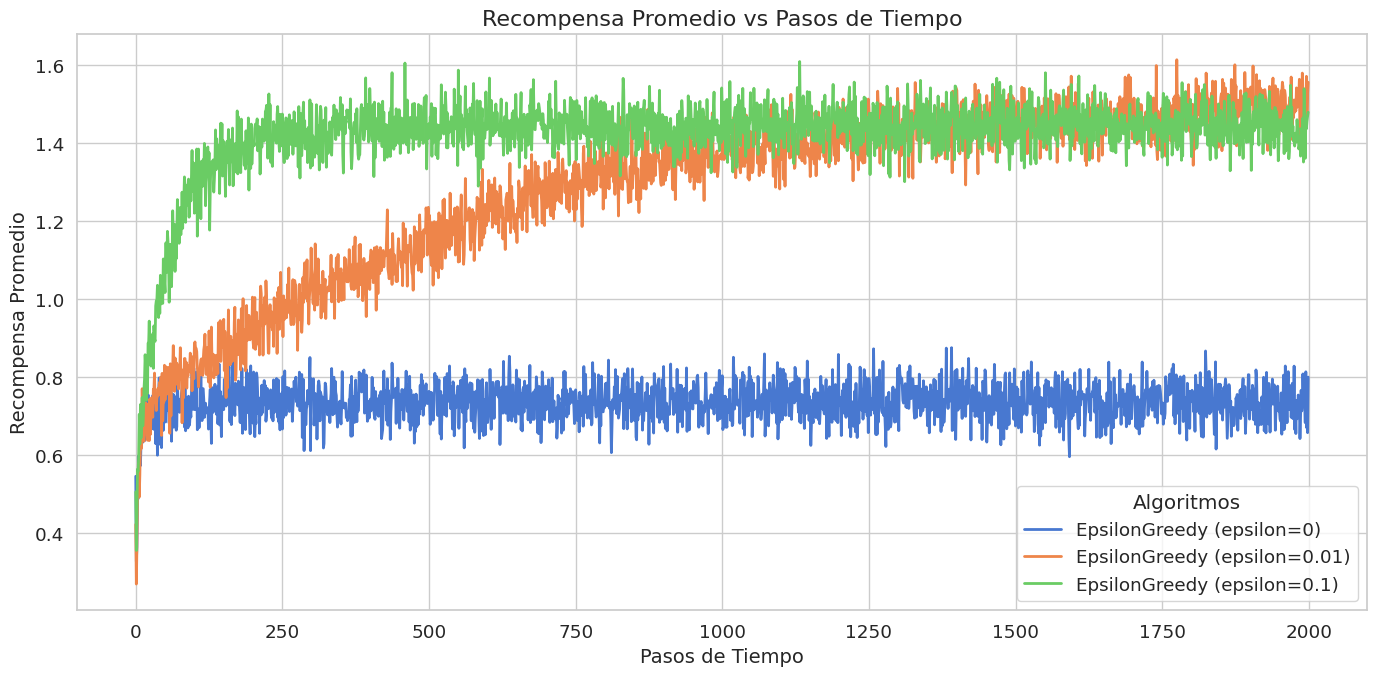

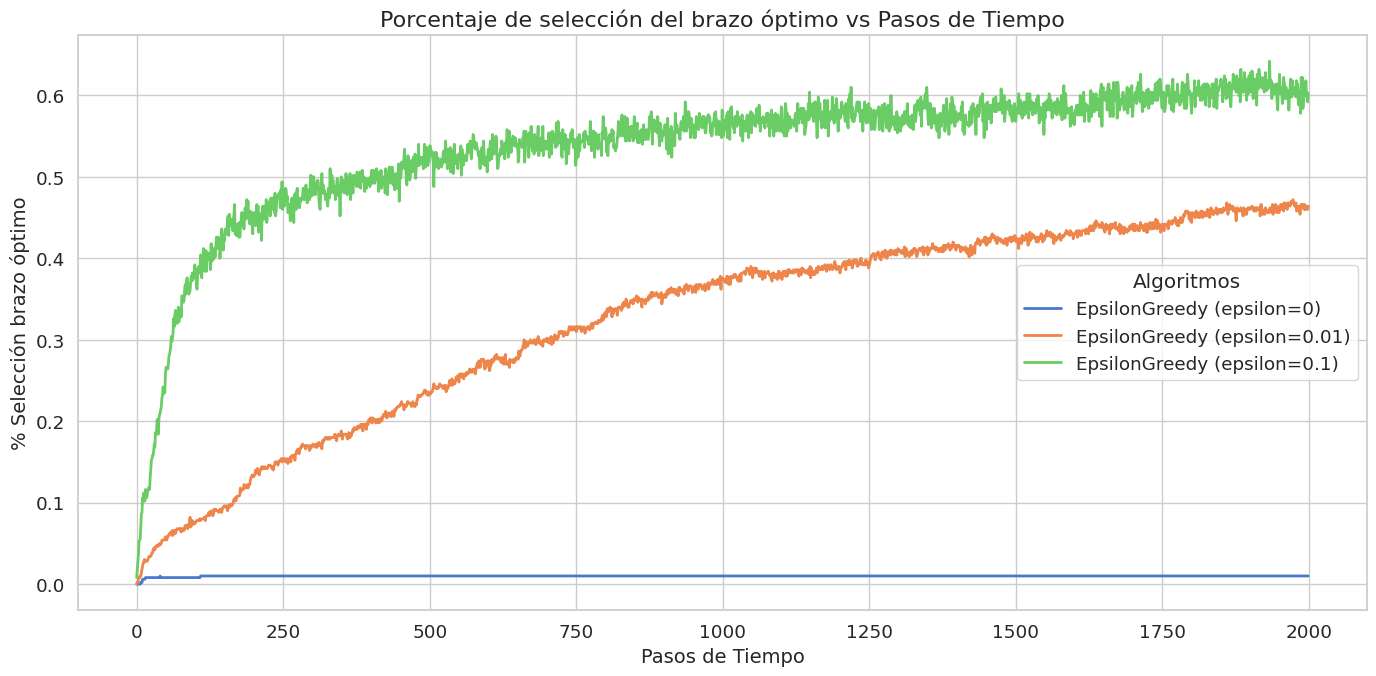

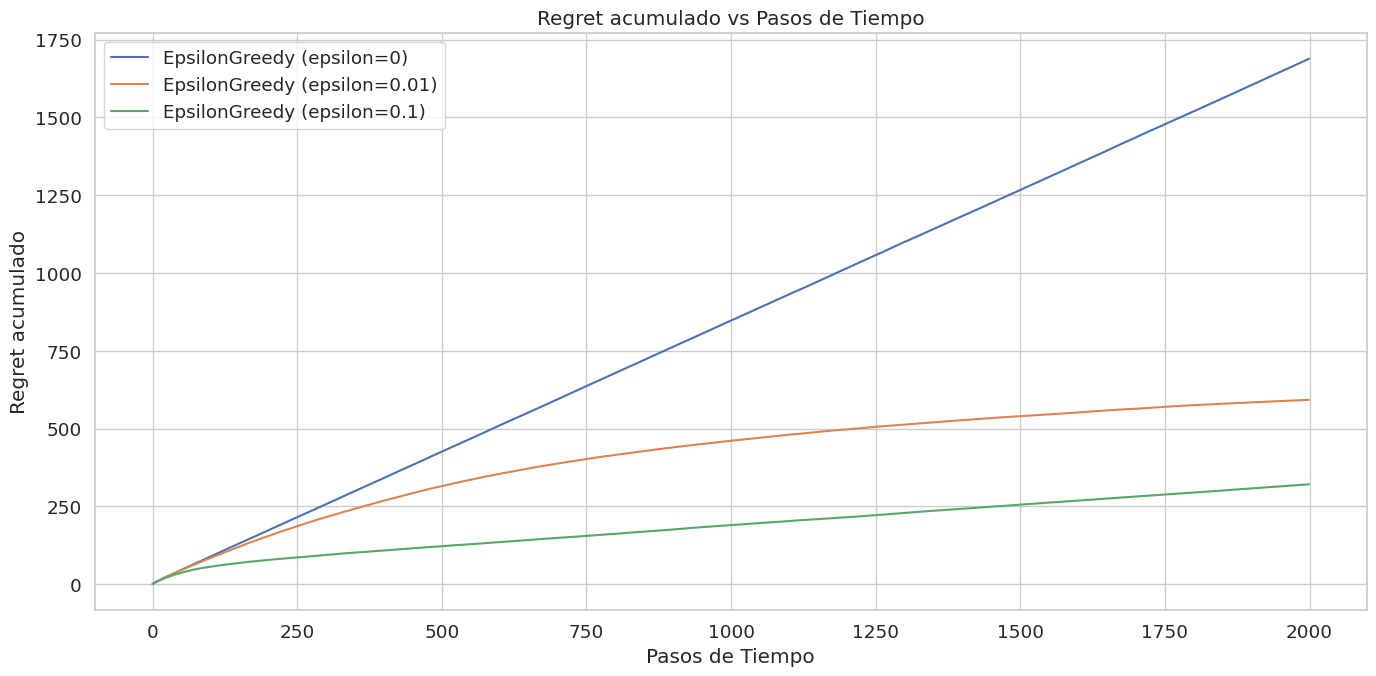


===== k = 20 =====


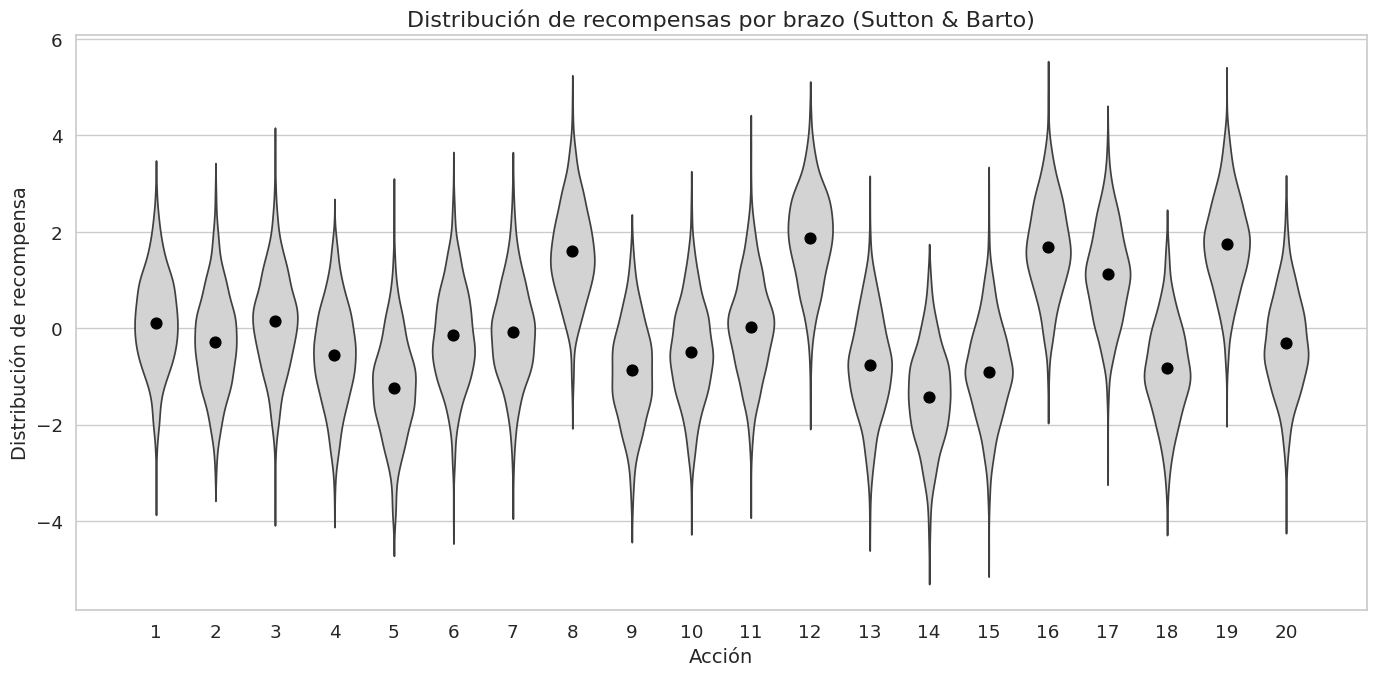

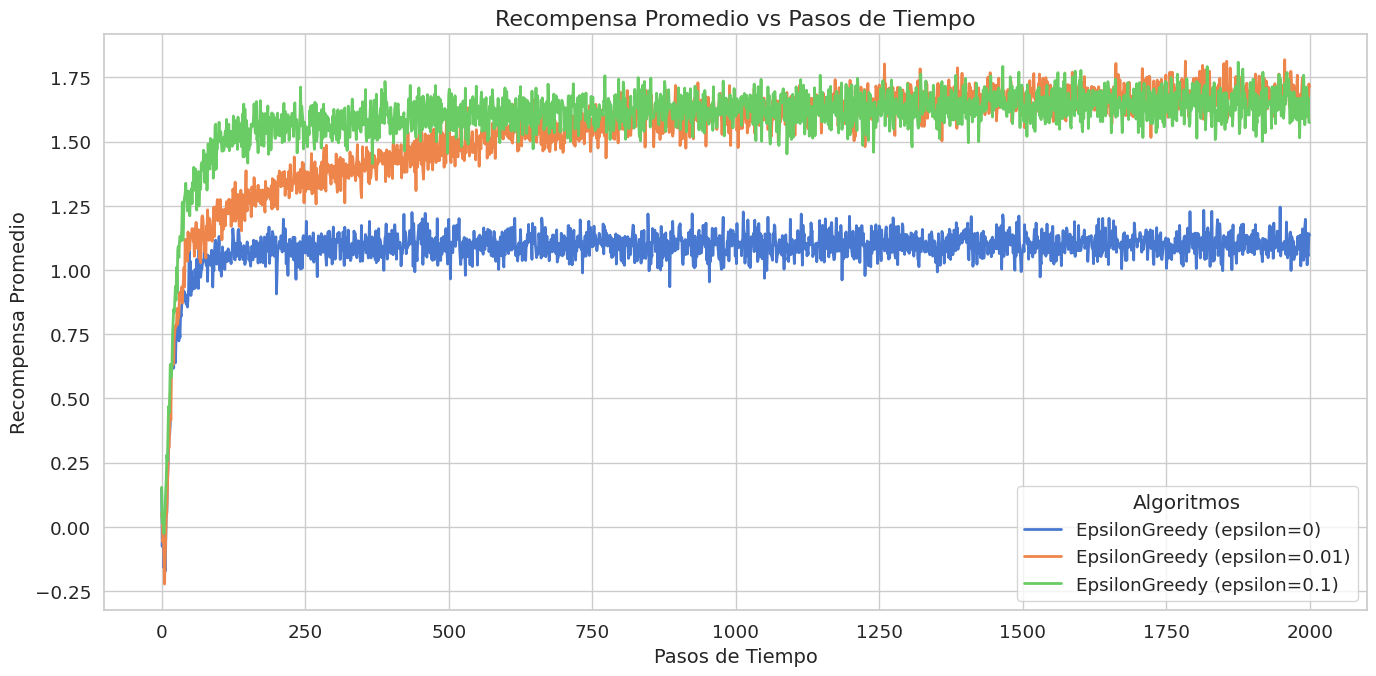

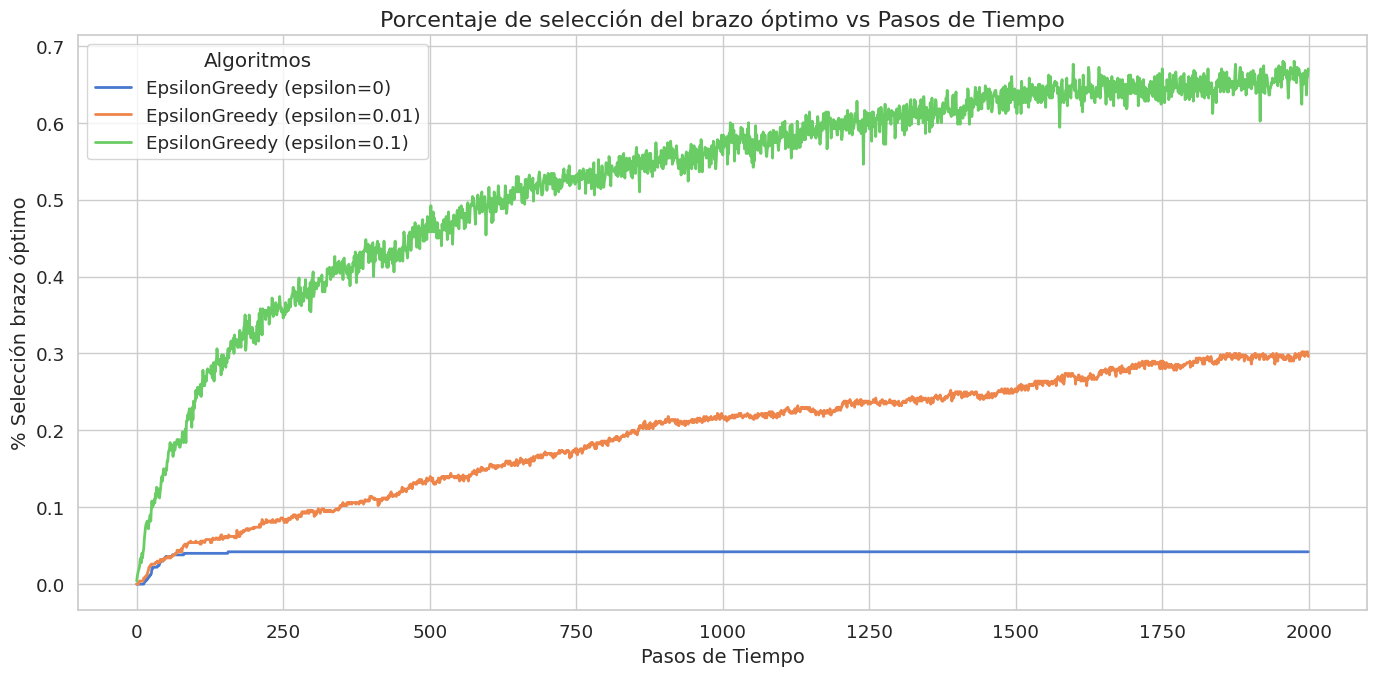

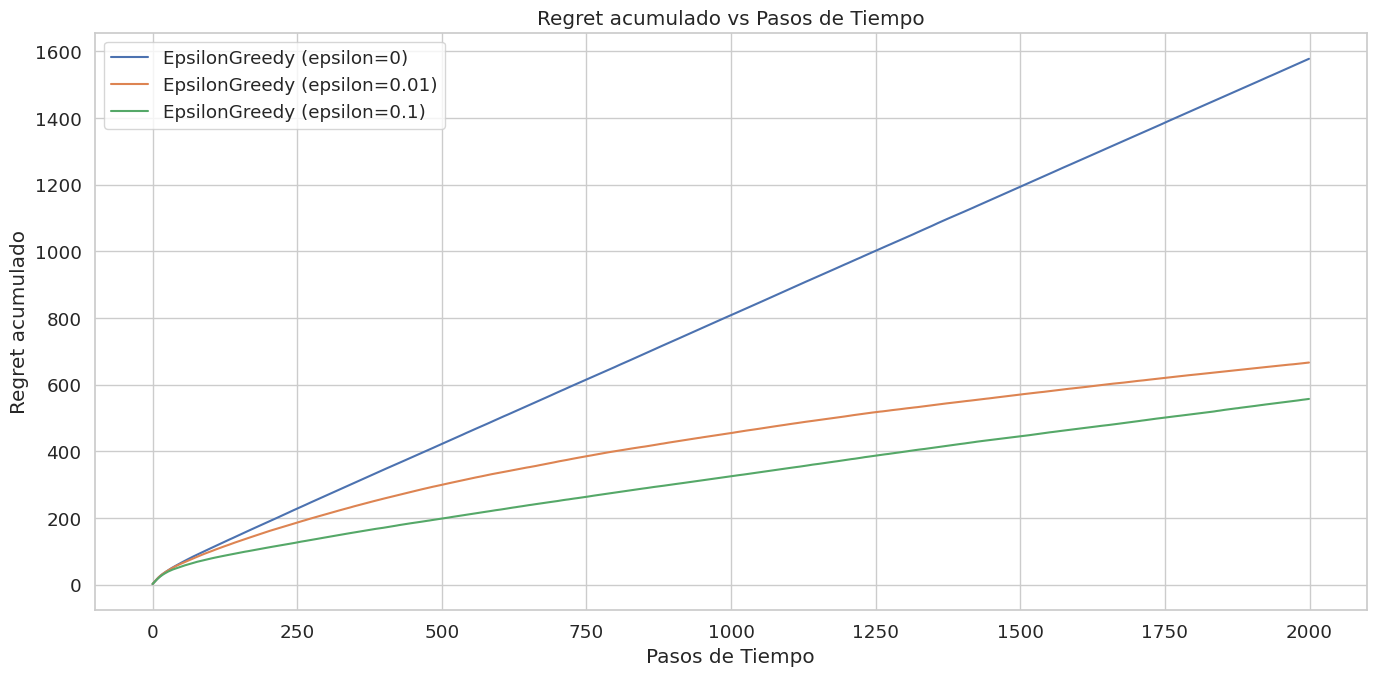


===== k = 100 =====


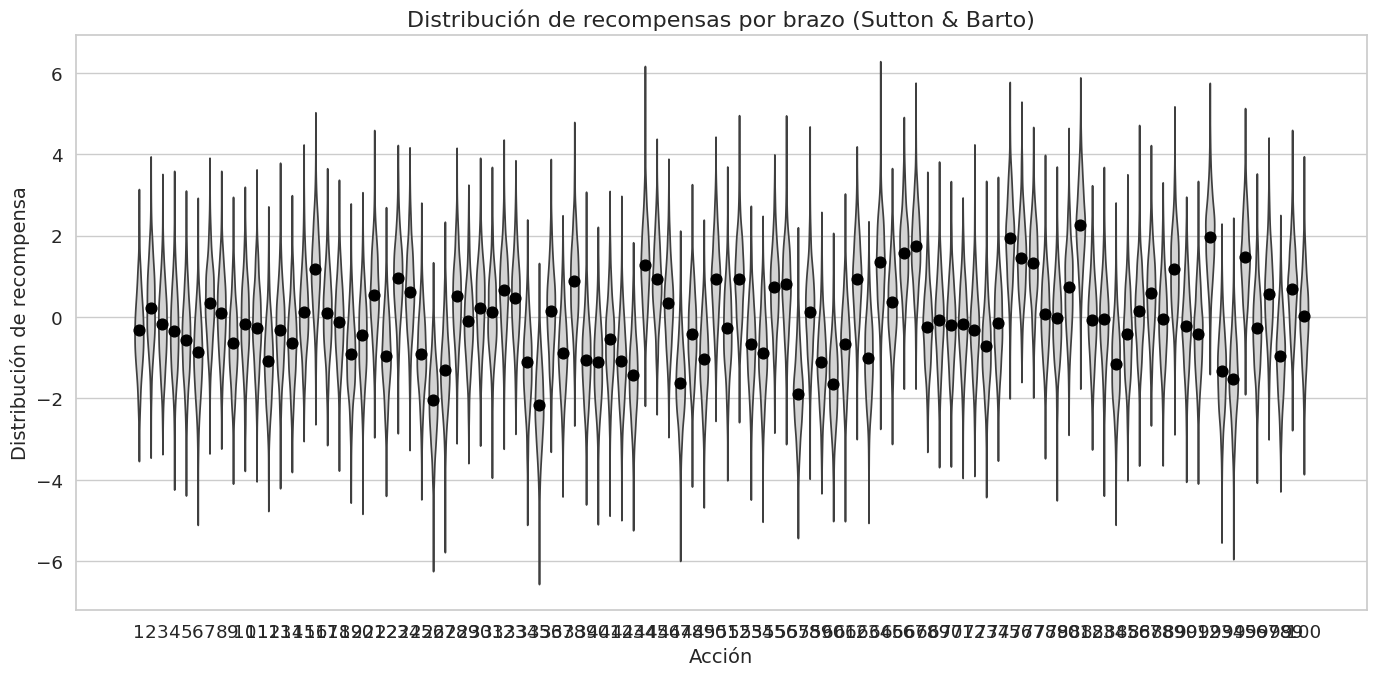

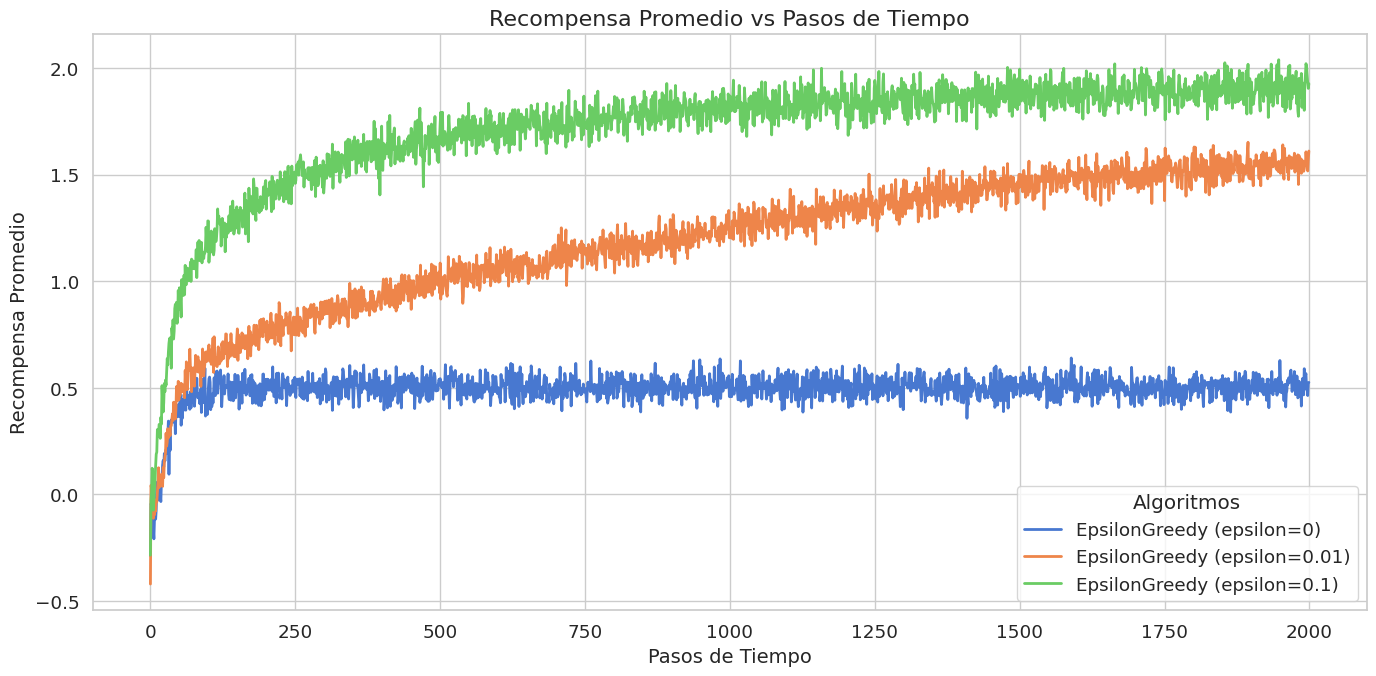

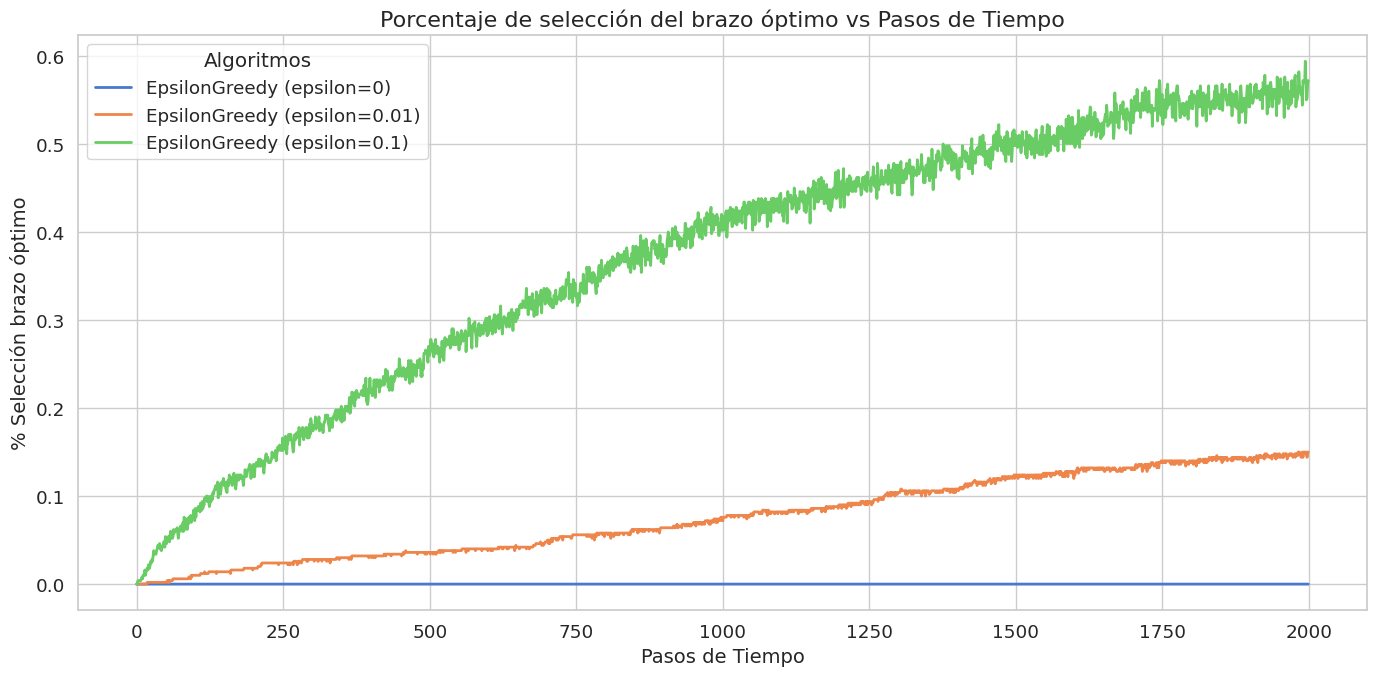

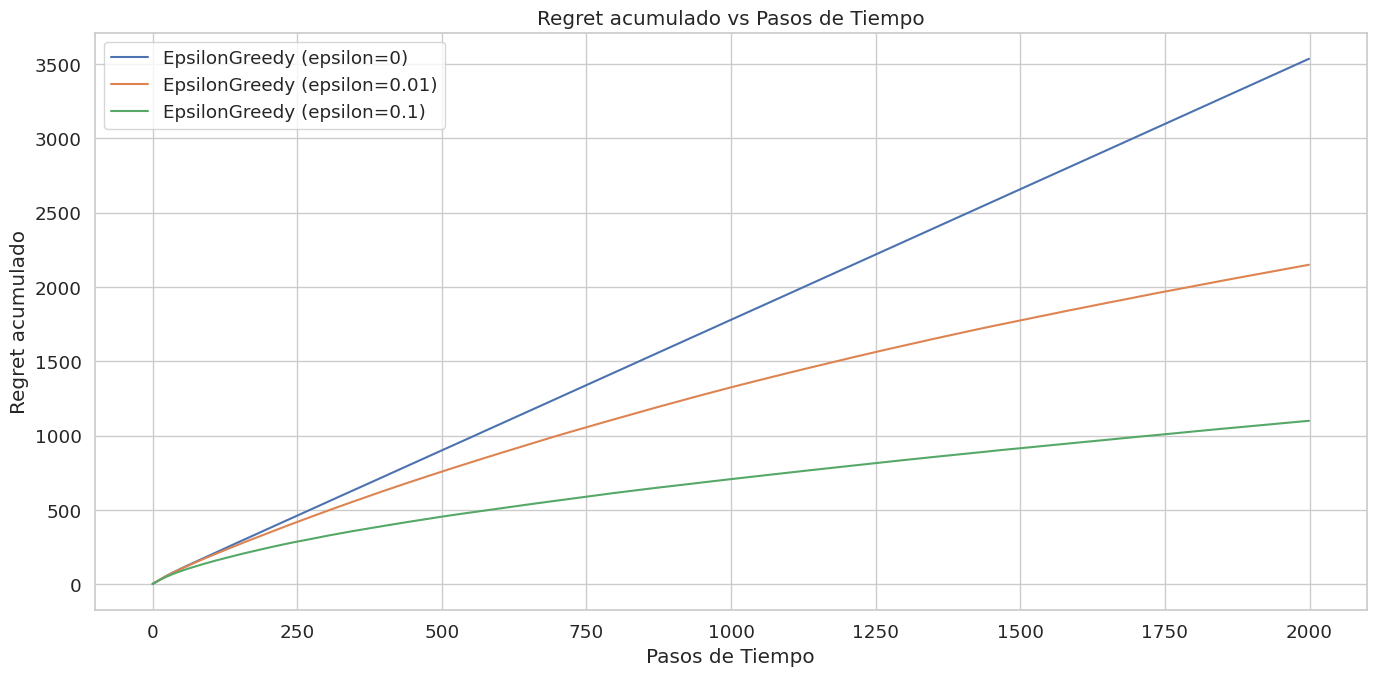

In [34]:


# =====================================================
# EXPERIMENTO LOCAL
# =====================================================

def run_experiment_local(bandit, algorithms, steps, runs):

    n_algorithms = len(algorithms)

    rewards = np.zeros((n_algorithms, steps))
    optimal_selections = np.zeros((n_algorithms, steps))
    regret = np.zeros((n_algorithms, steps))

    optimal_arm = bandit.get_optimal_arm()
    optimal_mean = bandit.arms[optimal_arm].get_expected_value()

    for run in range(runs):

        algos = [
            type(algo)(k=bandit.k, epsilon=algo.epsilon)
            for algo in algorithms
        ]

        for t in range(steps):

            for i, algo in enumerate(algos):

                arm_index = algo.select_arm()
                reward = bandit.pull_arm(arm_index)

                algo.update(arm_index, reward)

                rewards[i, t] += reward
                regret[i, t] += optimal_mean - reward

                if arm_index == optimal_arm:
                    optimal_selections[i, t] += 1

    rewards /= runs
    optimal_selections /= runs
    regret /= runs

    cumulative_regret = np.cumsum(regret, axis=1)

    return rewards, optimal_selections, cumulative_regret


# =====================================================
# PARÁMETROS
# =====================================================

steps = 2000
runs = 500

k_values = [10, 20, 100]
epsilon_values = [0, 0.01, 0.1]

sigma = 1


# =====================================================
# EXPERIMENTOS
# =====================================================

for k in k_values:

    print(f"\n===== k = {k} =====")

    mu_values = np.random.normal(0, 1, k)
    arms = [ArmNormal(mu, sigma) for mu in mu_values]

    # 🎻 Sutton & Barto
    plot_reward_distributions(arms)

    bandit = Bandit(arms)

    algorithms = [
        EpsilonGreedy(k=k, epsilon=e)
        for e in epsilon_values
    ]

    rewards, optimal_selections, cumulative_regret = run_experiment_local(
        bandit=bandit,
        algorithms=algorithms,
        steps=steps,
        runs=runs
    )

    # 📈 Gráficas oficiales
    plot_average_rewards(steps, rewards, algorithms)
    plot_optimal_selections(steps, optimal_selections, algorithms)

    # 📉 Regret acumulado (tu función en regacu.py)
    plot_cumulative_regret(steps, cumulative_regret, algorithms)

# A) Recompensa Promedio

Comportamiento observado:

ε = 0 (Greedy puro)

Rápida convergencia inicial.

Alta probabilidad de quedar atrapado en un brazo subóptimo.

Alta varianza entre ejecuciones.

ε = 0.1 (Exploración alta)

Aprendizaje rápido del brazo óptimo.

Rendimiento estable.

Nunca alcanza el máximo posible debido a exploración constante (10%).

ε = 0.01 (Exploración baja)

Convergencia más lenta.

Mejor rendimiento a largo plazo.

Balance más eficiente exploración/explotación.

**En horizonte largo (2000 pasos), ε=0.01 domina en recompensa promedio.**



# B)% de Selección Óptima

ε=0.1 alcanza rápidamente alto porcentaje.

ε=0.01 tarda más, pero supera a largo plazo.

Greedy es inconsistente.

**El porcentaje óptimo confirma que explorar ligeramente mejora la estabilidad.**



# C) Regret Acumulado

Greedy muestra crecimiento casi lineal cuando falla.

ε=0.1 crece moderadamente.

ε=0.01 tiende a crecimiento sublineal.

**Regret acumulado es la métrica más importante, ya que integra el costo total del aprendizaje.**

# **ArmBernoulli**

# ε = 0, 0.01, 0.1

# k = 10, 20, 100

# Semilla fija




===== k = 10 =====


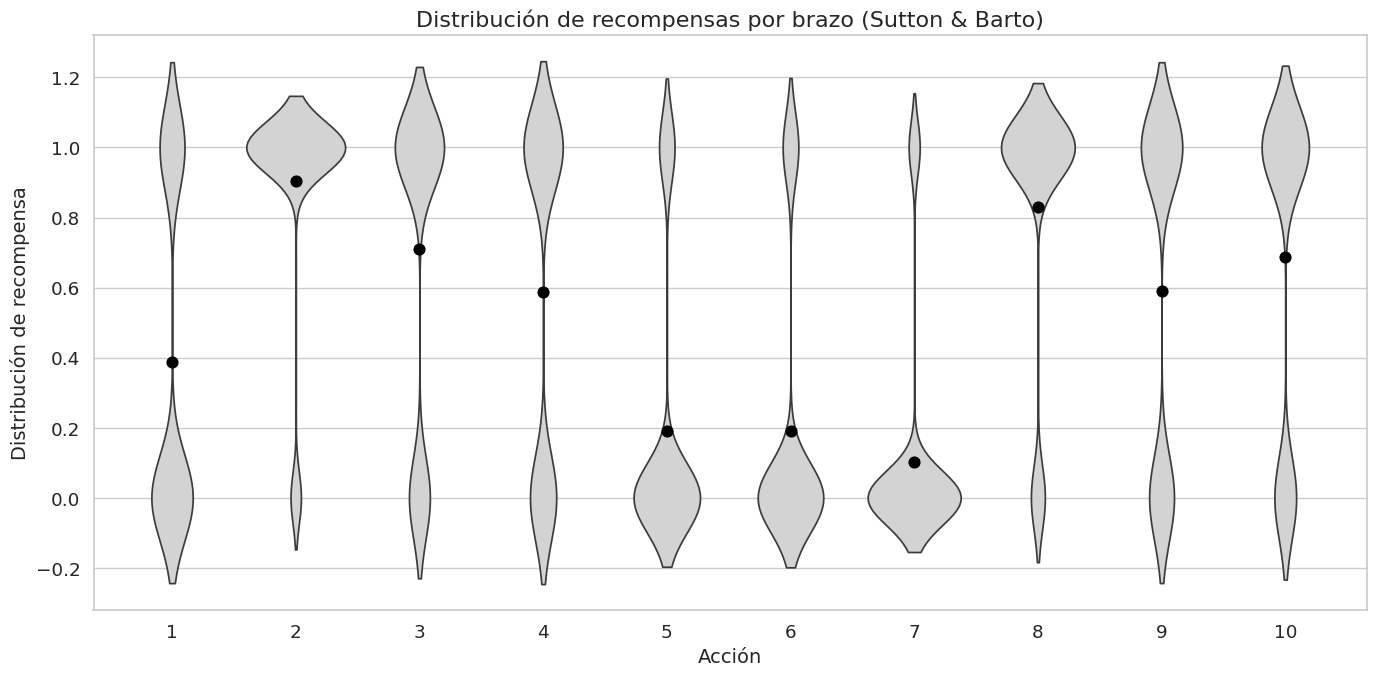

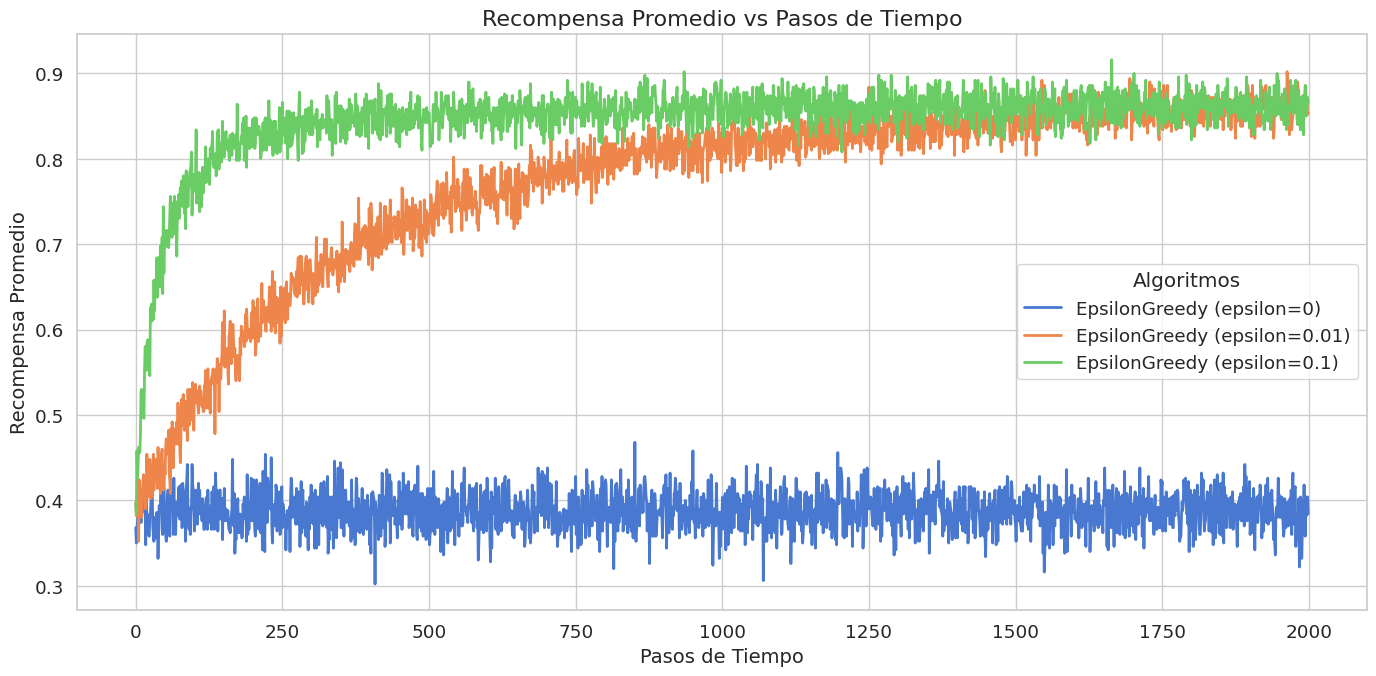

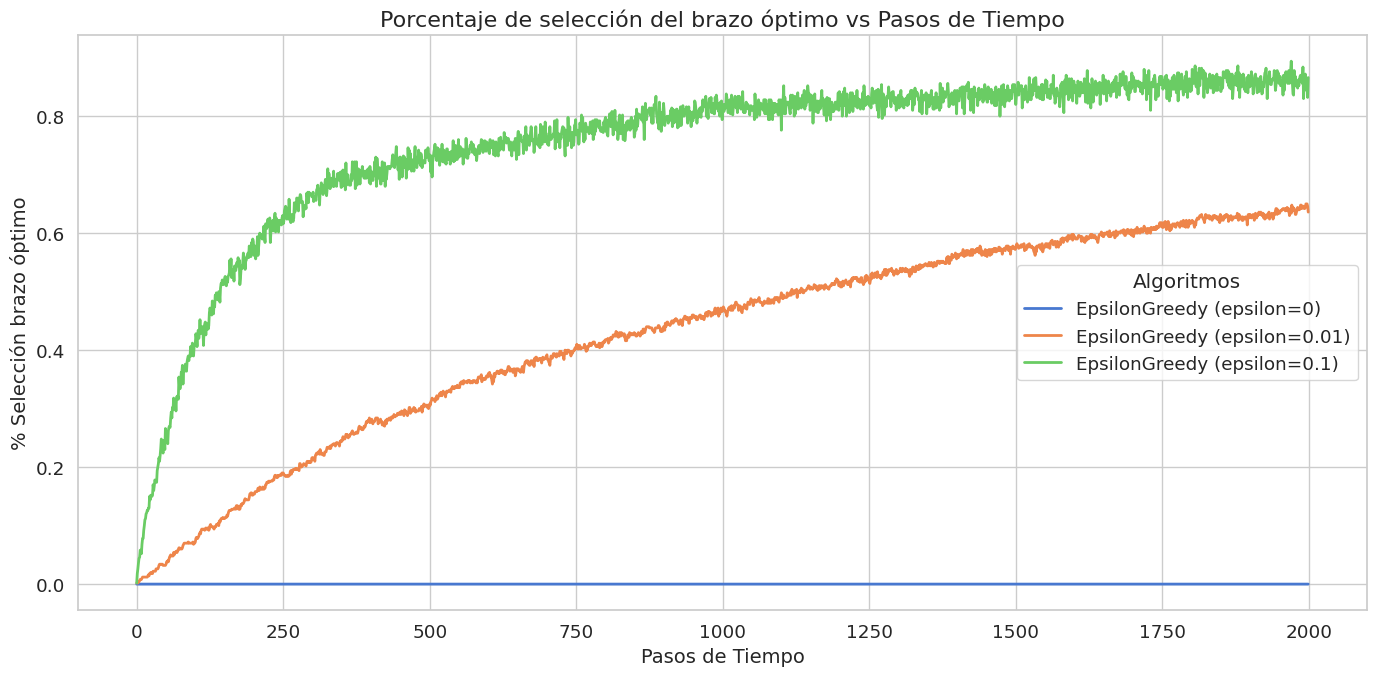

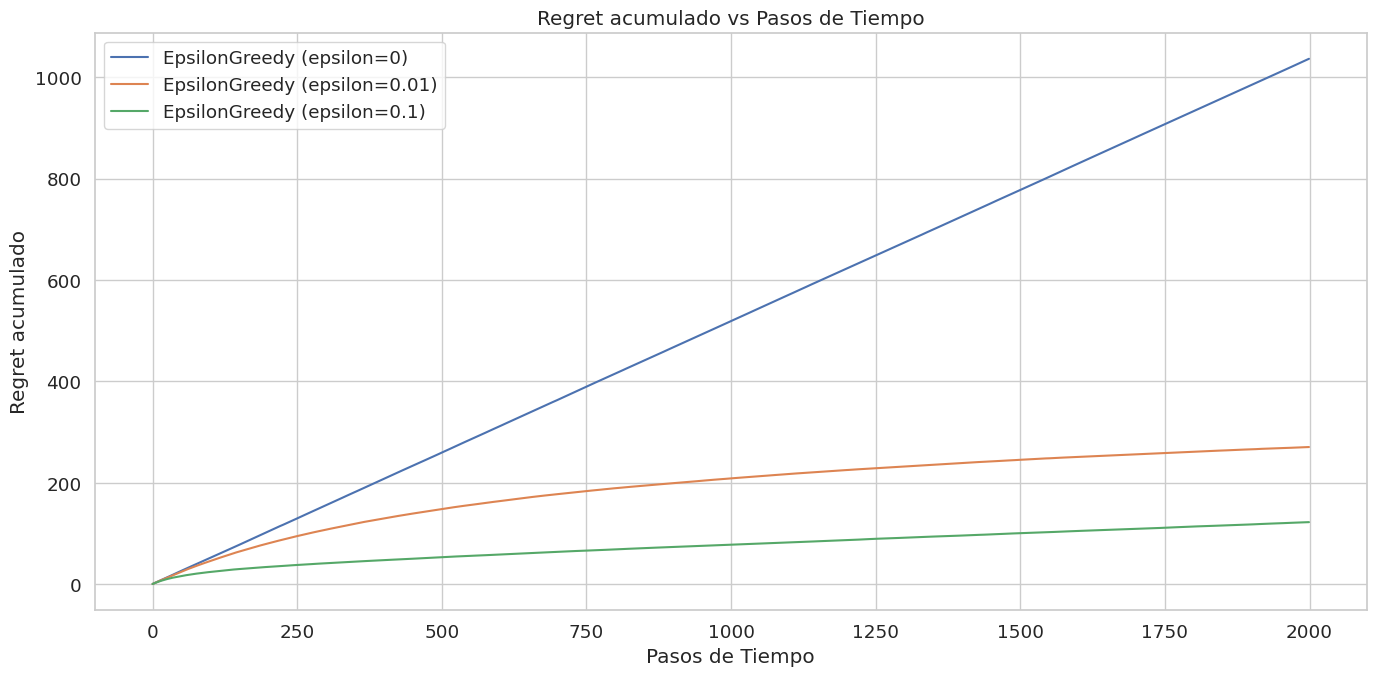


===== k = 20 =====


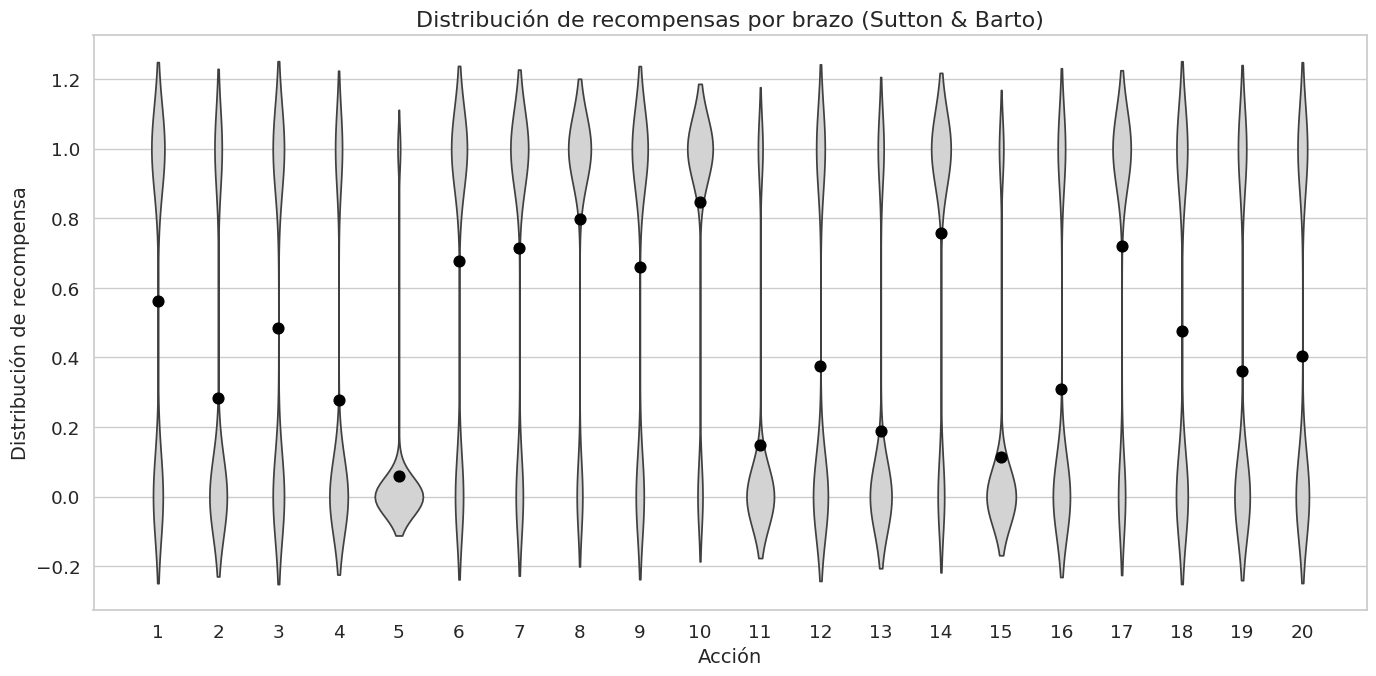

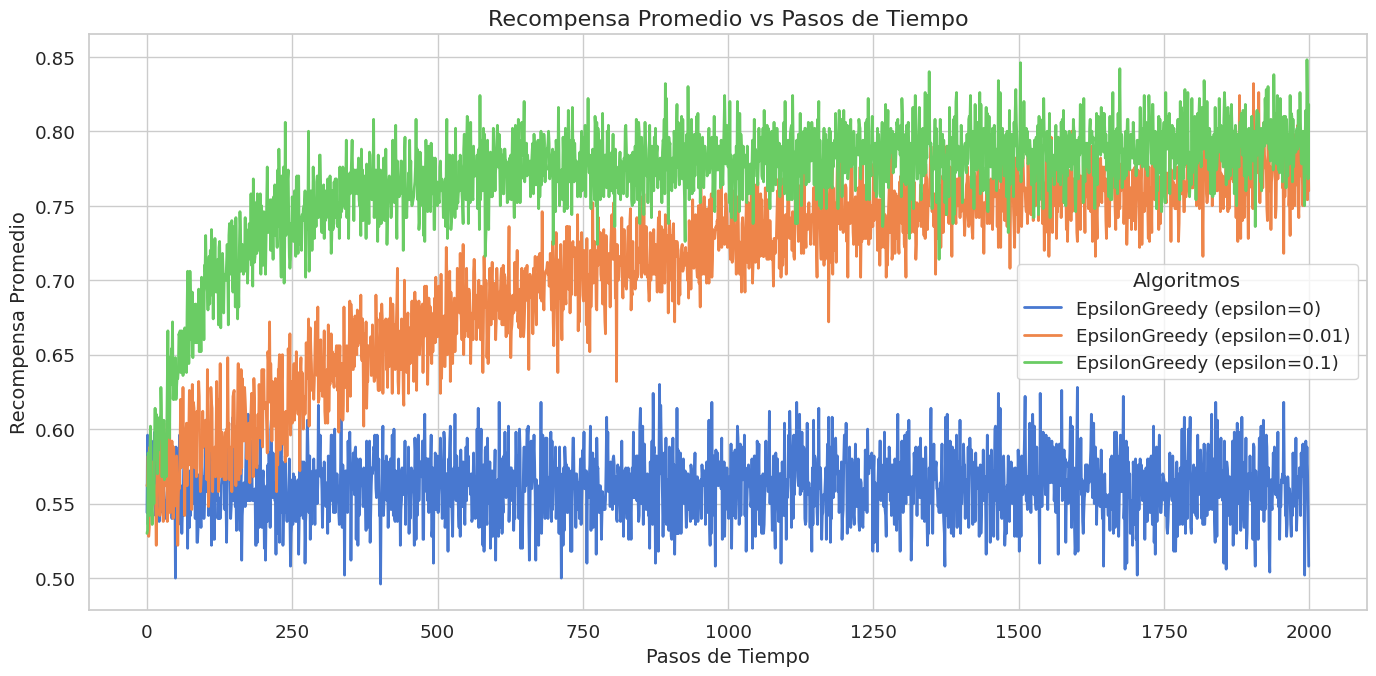

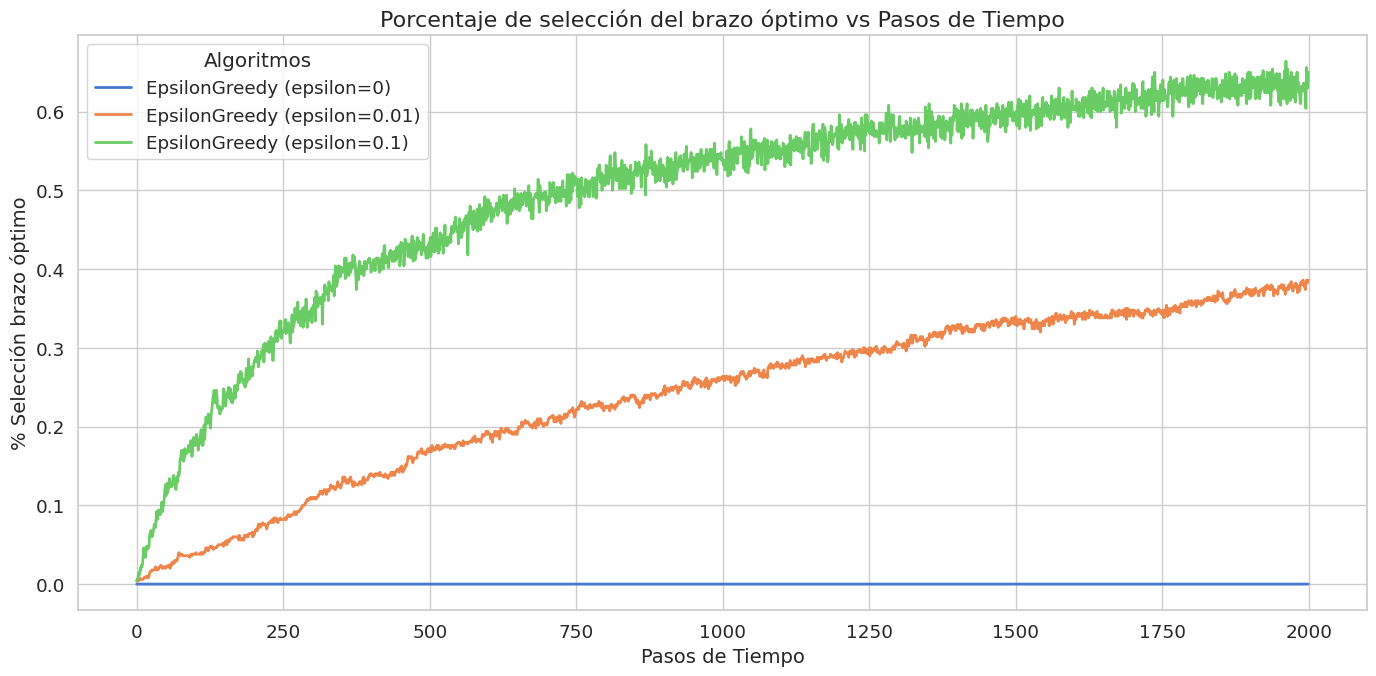

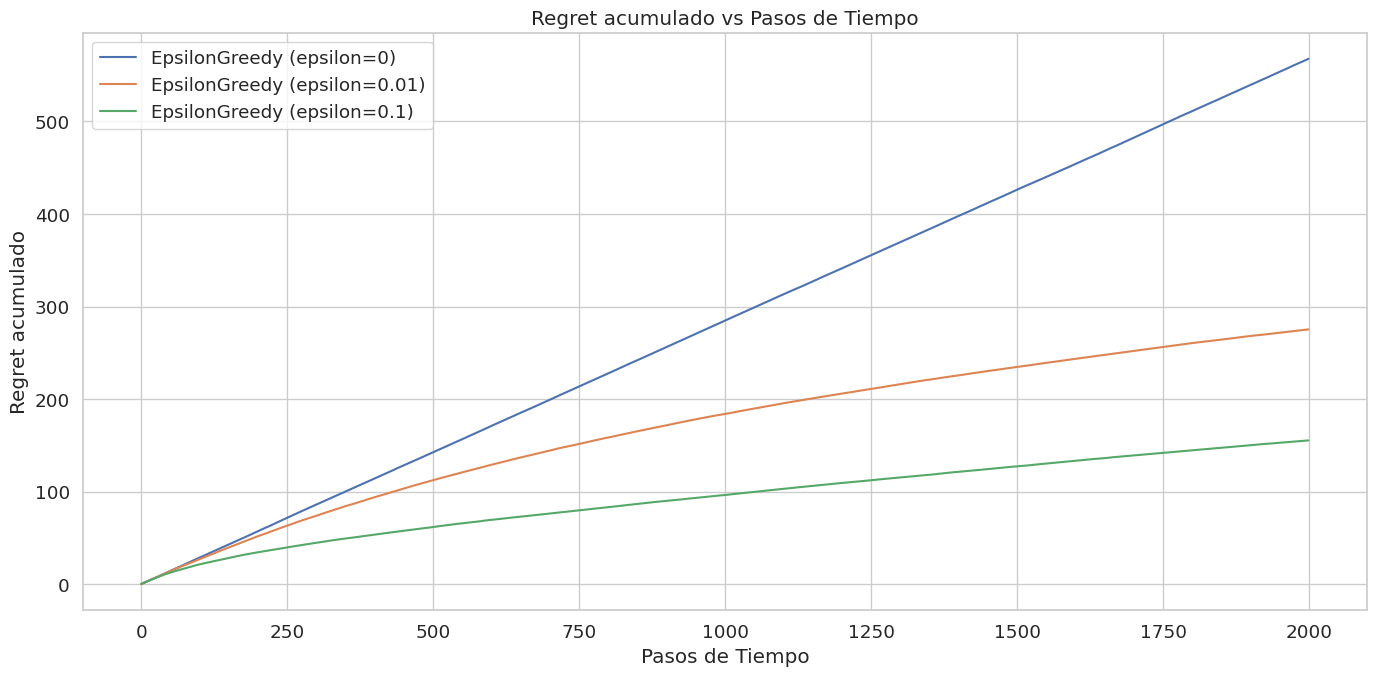


===== k = 100 =====


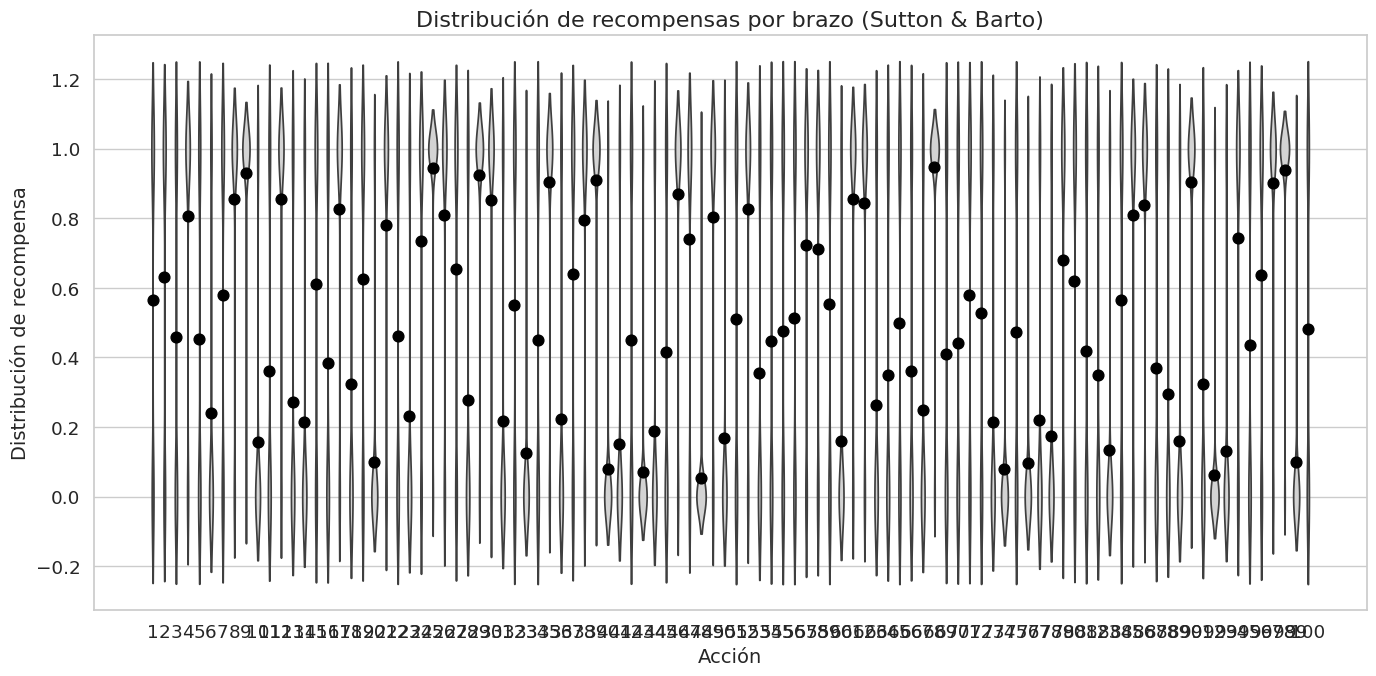

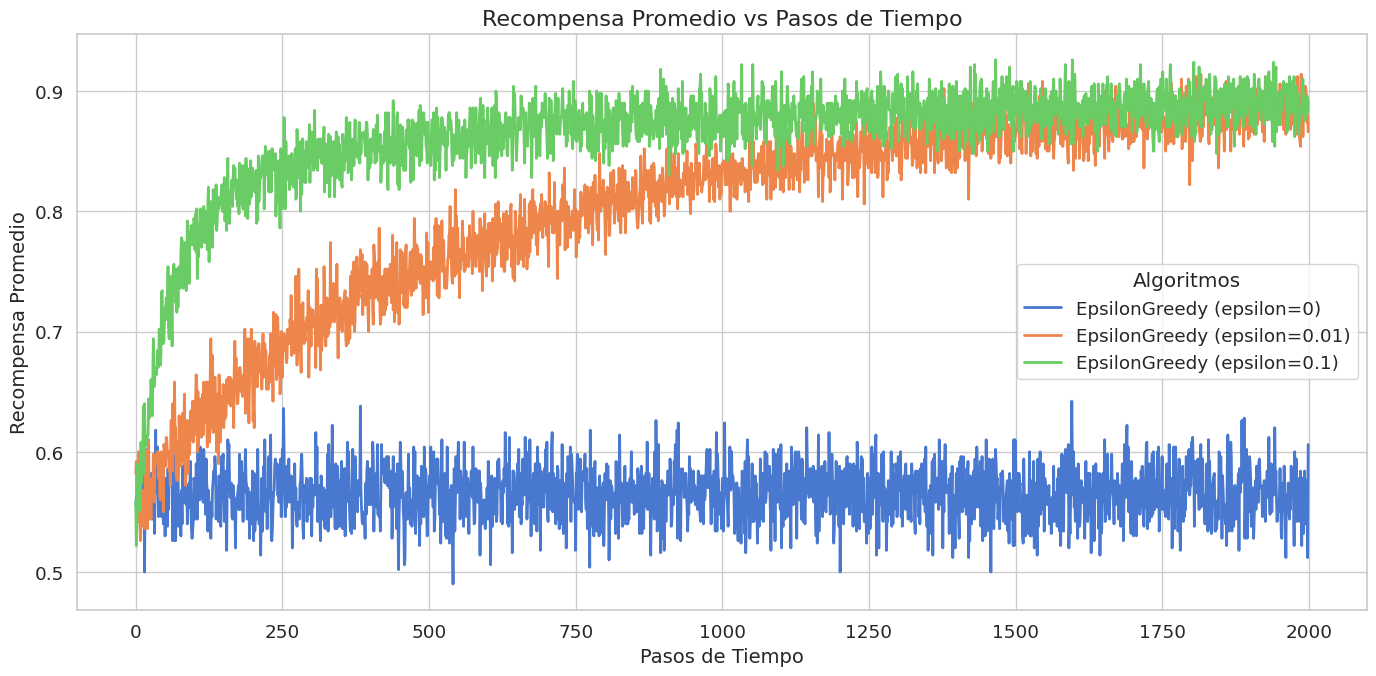

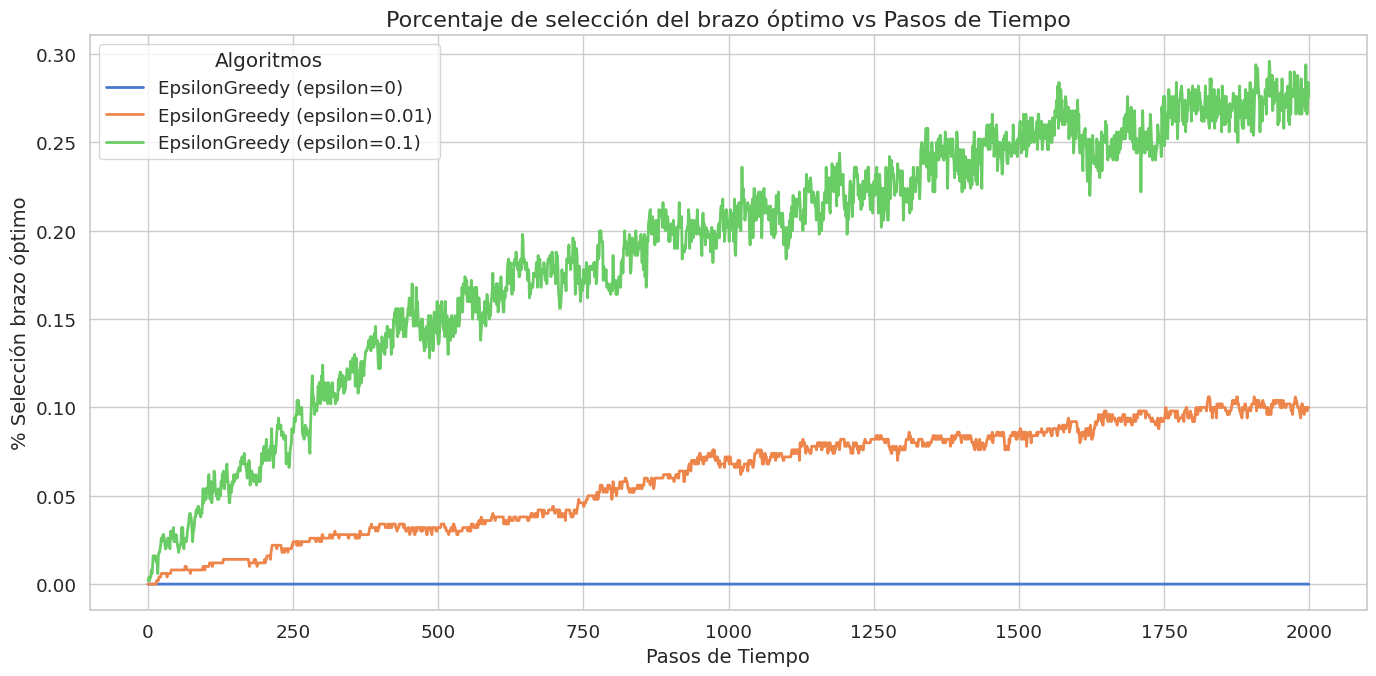

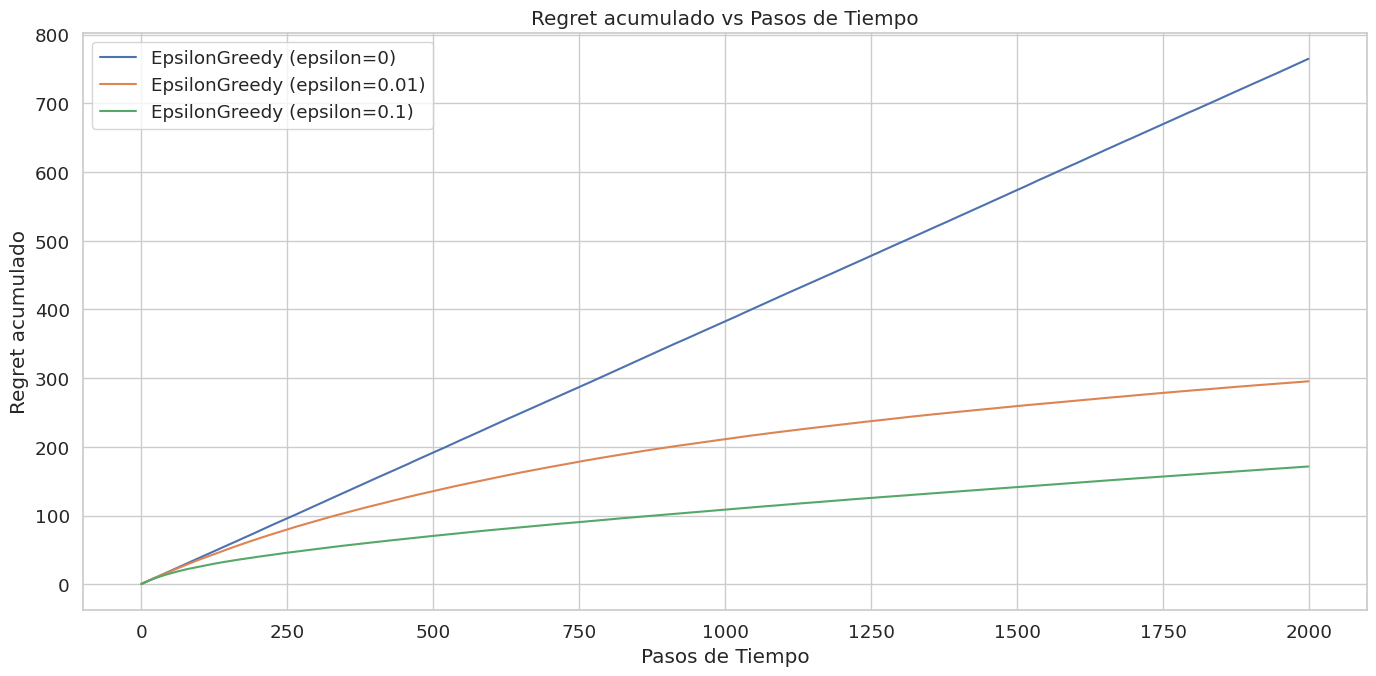

In [35]:


# =====================================================
# FUNCIÓN EXPERIMENTO LOCAL
# =====================================================

def run_experiment_local(bandit, algorithms, steps, runs):

    n_algorithms = len(algorithms)

    rewards = np.zeros((n_algorithms, steps))
    optimal_selections = np.zeros((n_algorithms, steps))
    regret = np.zeros((n_algorithms, steps))

    optimal_arm = bandit.get_optimal_arm()
    optimal_mean = bandit.arms[optimal_arm].get_expected_value()

    for run in range(runs):

        algos = [
            type(algo)(k=bandit.k, epsilon=algo.epsilon)
            for algo in algorithms
        ]

        for t in range(steps):

            for i, algo in enumerate(algos):

                arm_index = algo.select_arm()
                reward = bandit.pull_arm(arm_index)

                algo.update(arm_index, reward)

                rewards[i, t] += reward
                regret[i, t] += optimal_mean - reward

                if arm_index == optimal_arm:
                    optimal_selections[i, t] += 1

    rewards /= runs
    optimal_selections /= runs
    regret /= runs

    cumulative_regret = np.cumsum(regret, axis=1)

    return rewards, optimal_selections, cumulative_regret


# =====================================================
# PARÁMETROS
# =====================================================

steps = 2000
runs = 500

k_values = [10, 20, 100]
epsilon_values = [0, 0.01, 0.1]


# =====================================================
# EXPERIMENTOS
# =====================================================

for k in k_values:

    print(f"\n===== k = {k} =====")

    # Probabilidades Bernoulli
    p_values = np.random.uniform(0.05, 0.95, k)
    arms = [ArmBernoulli(p) for p in p_values]

    # 🎻 Sutton & Barto
    plot_reward_distributions(arms)

    bandit = Bandit(arms)

    algorithms = [
        EpsilonGreedy(k=k, epsilon=e)
        for e in epsilon_values
    ]

    rewards, optimal_selections, cumulative_regret = run_experiment_local(
        bandit=bandit,
        algorithms=algorithms,
        steps=steps,
        runs=runs
    )

    # 📈 Gráficas oficiales
    plot_average_rewards(steps, rewards, algorithms)
    plot_optimal_selections(steps, optimal_selections, algorithms)

    # 📉 Regret acumulado
    plot_cumulative_regret(steps, cumulative_regret, algorithms)

binominal

# **ArmBinomial**

# ε = 0, 0.01, 0.1

# k = 10, 20, 100

# n fijo

# Semilla reproducible



===== k = 10 =====


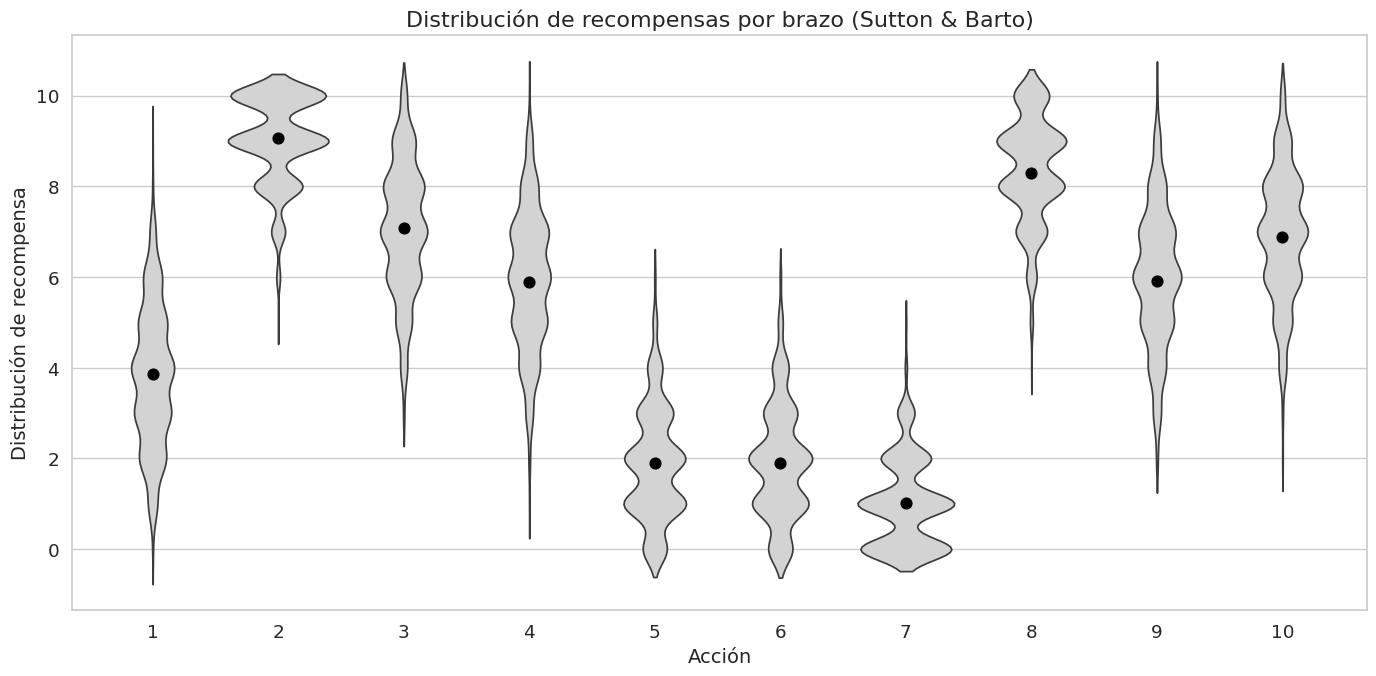

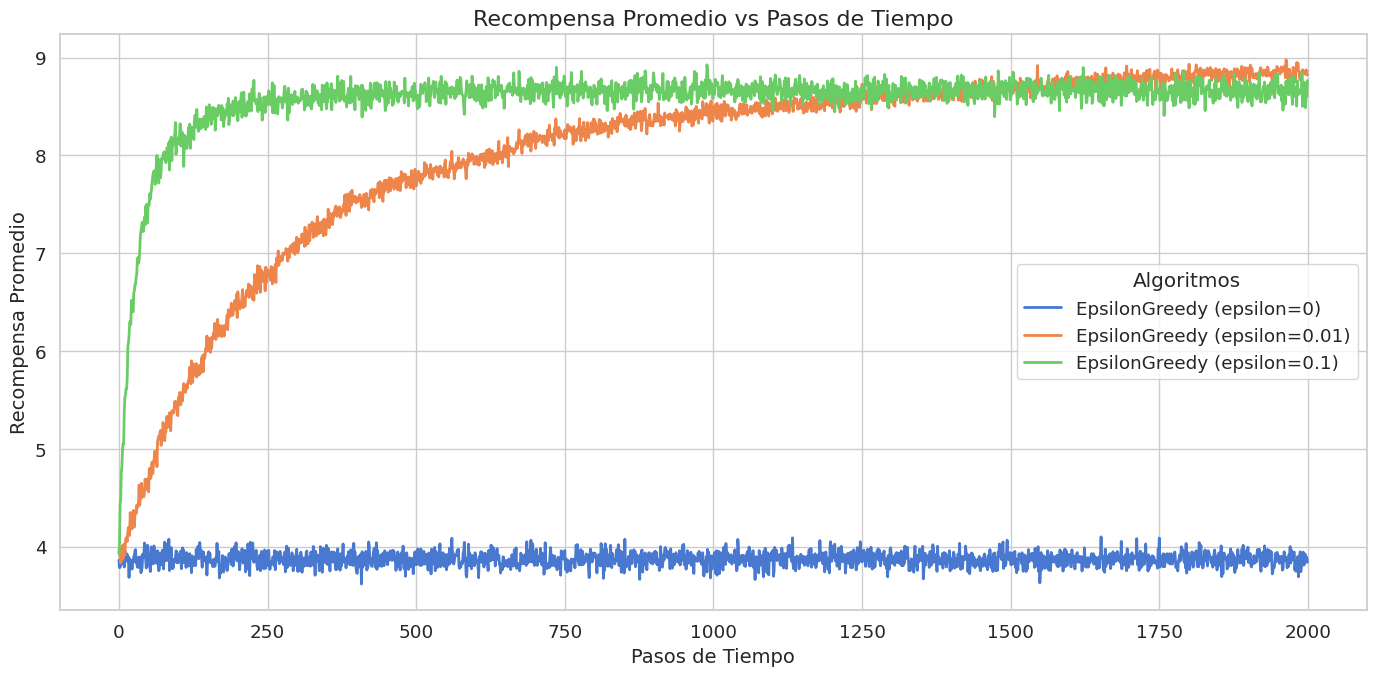

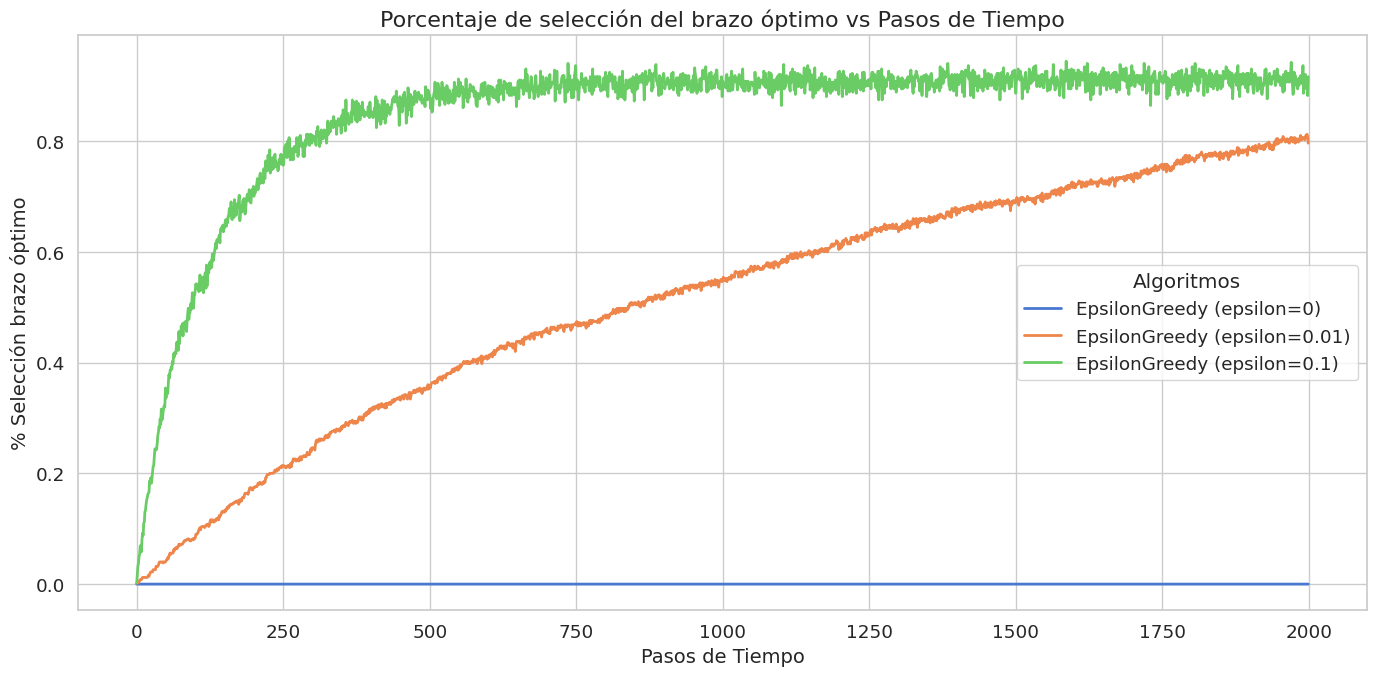

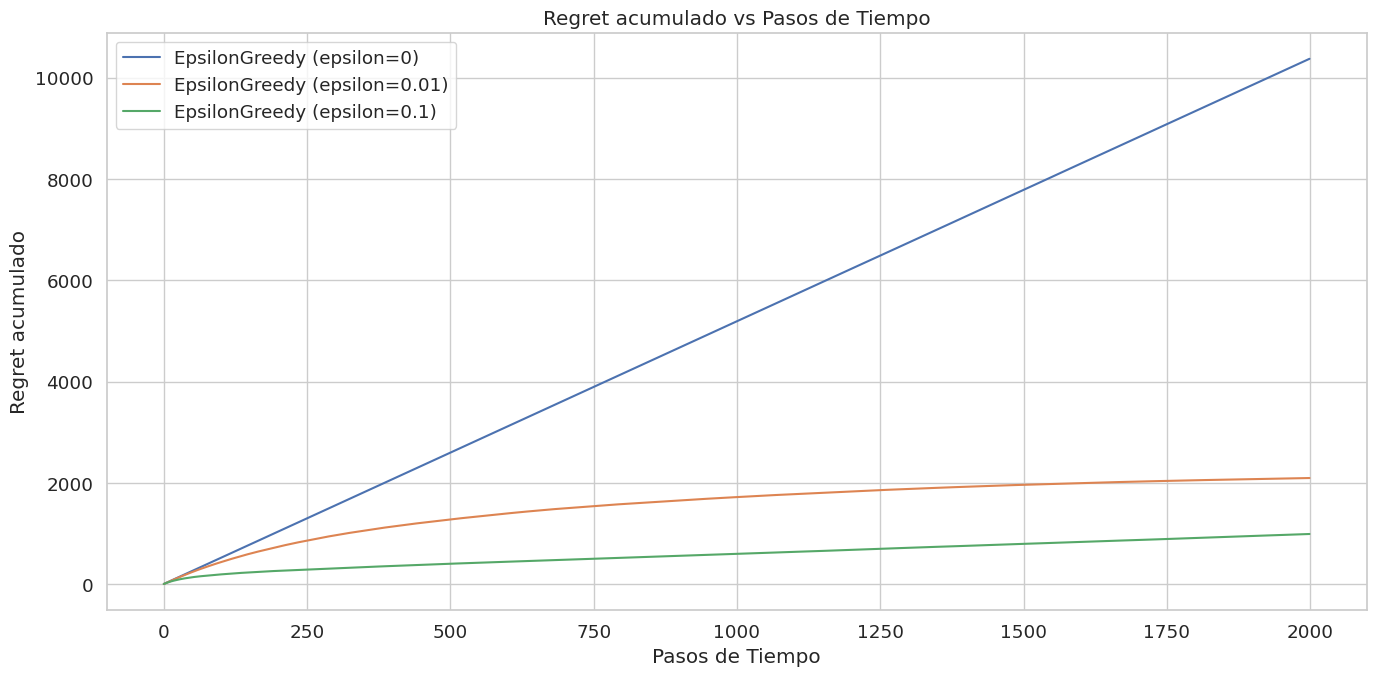


===== k = 20 =====


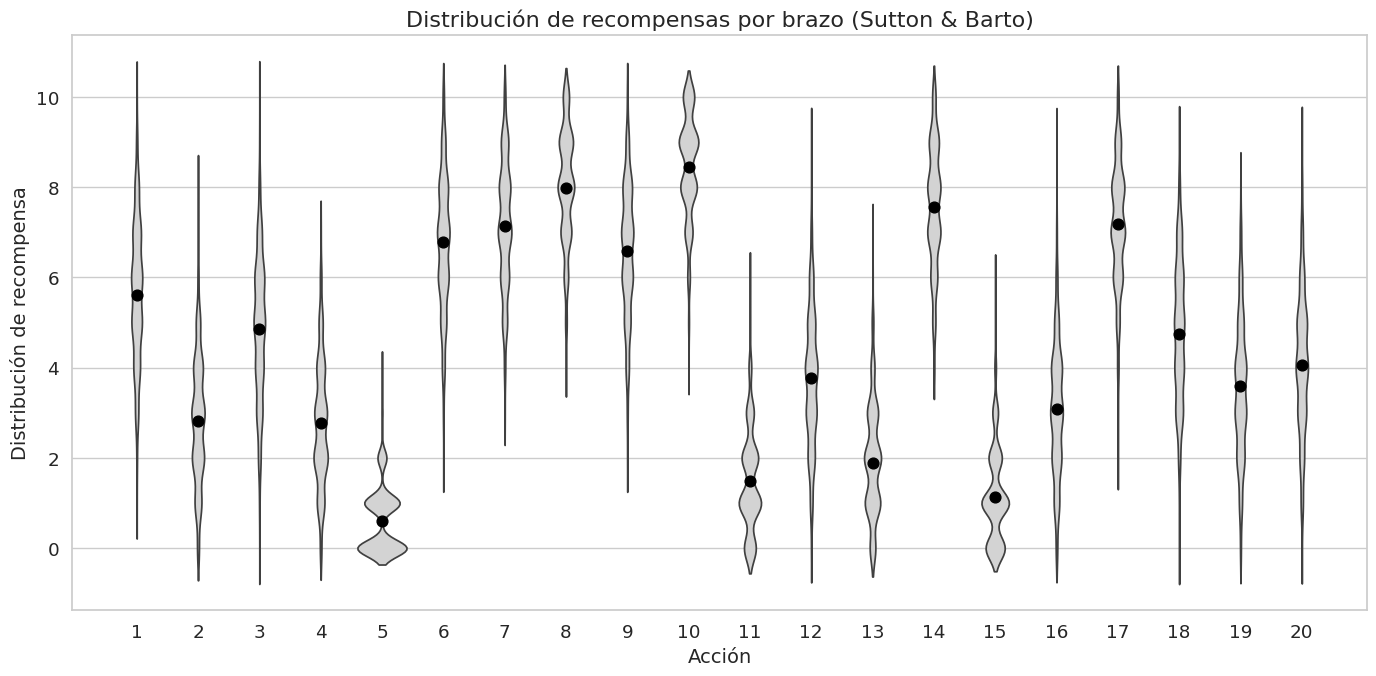

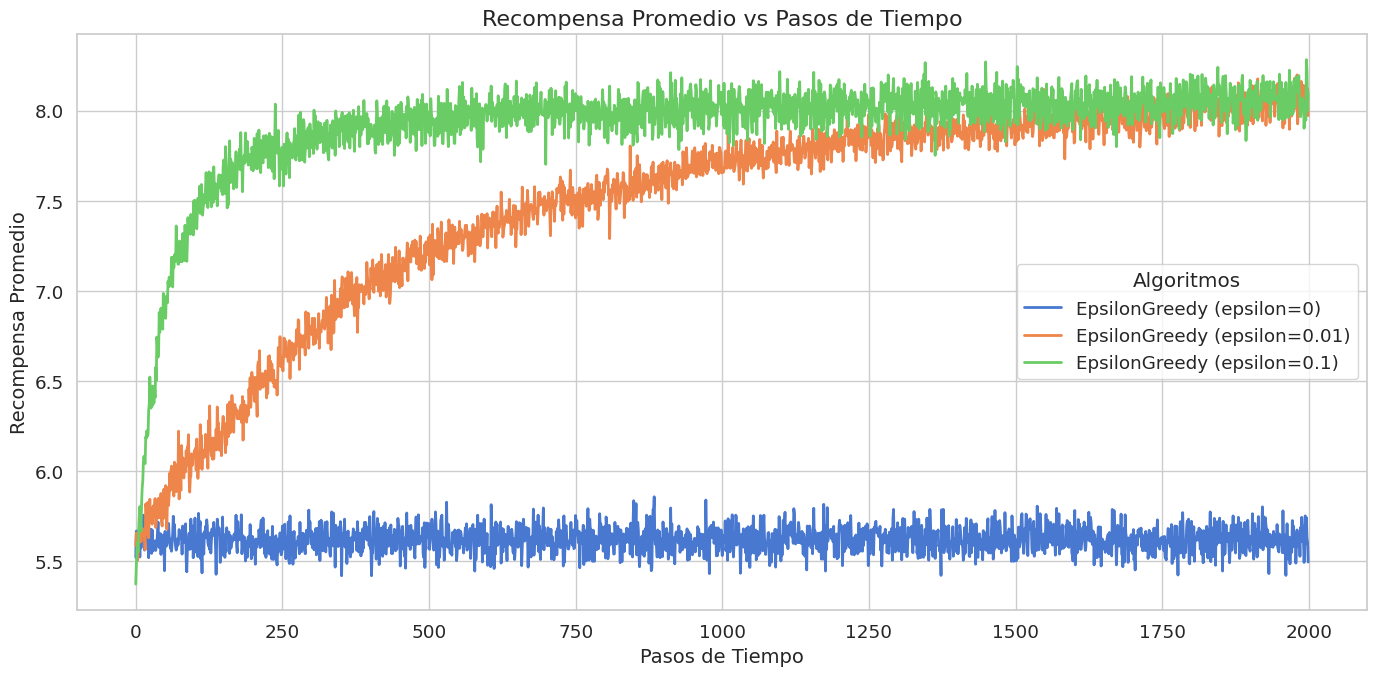

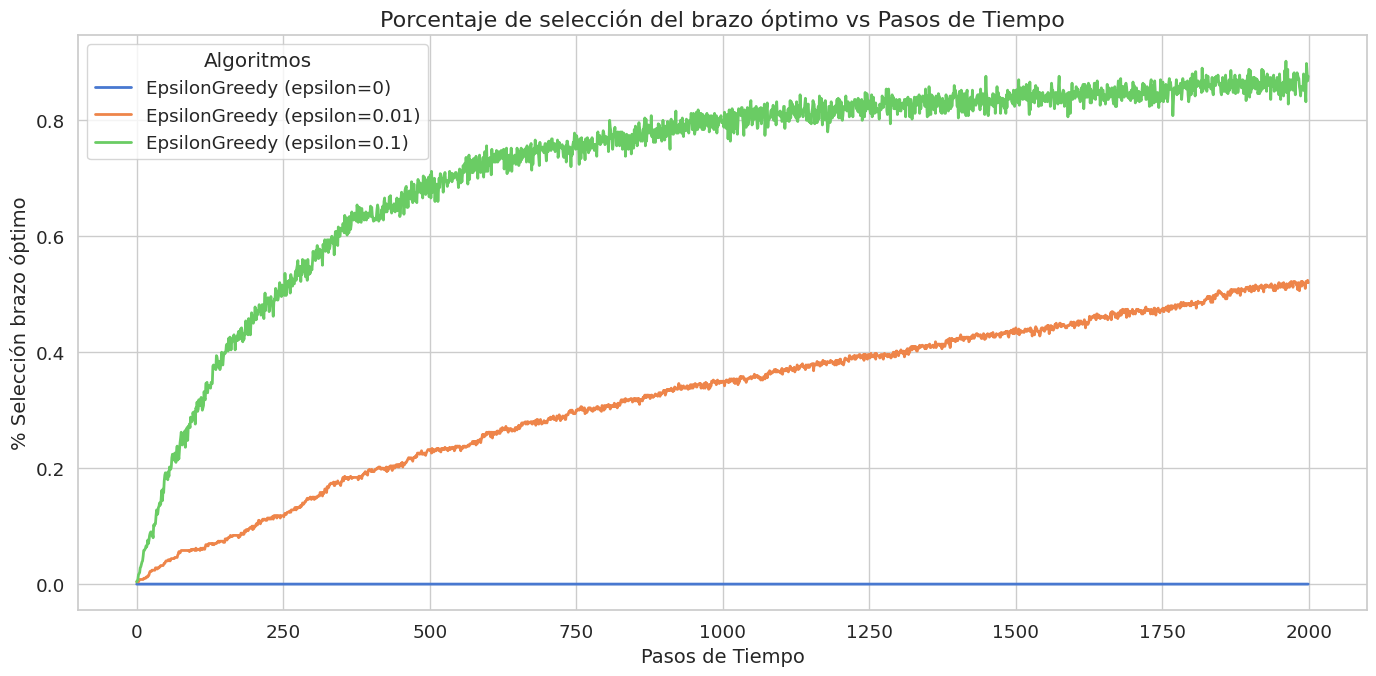

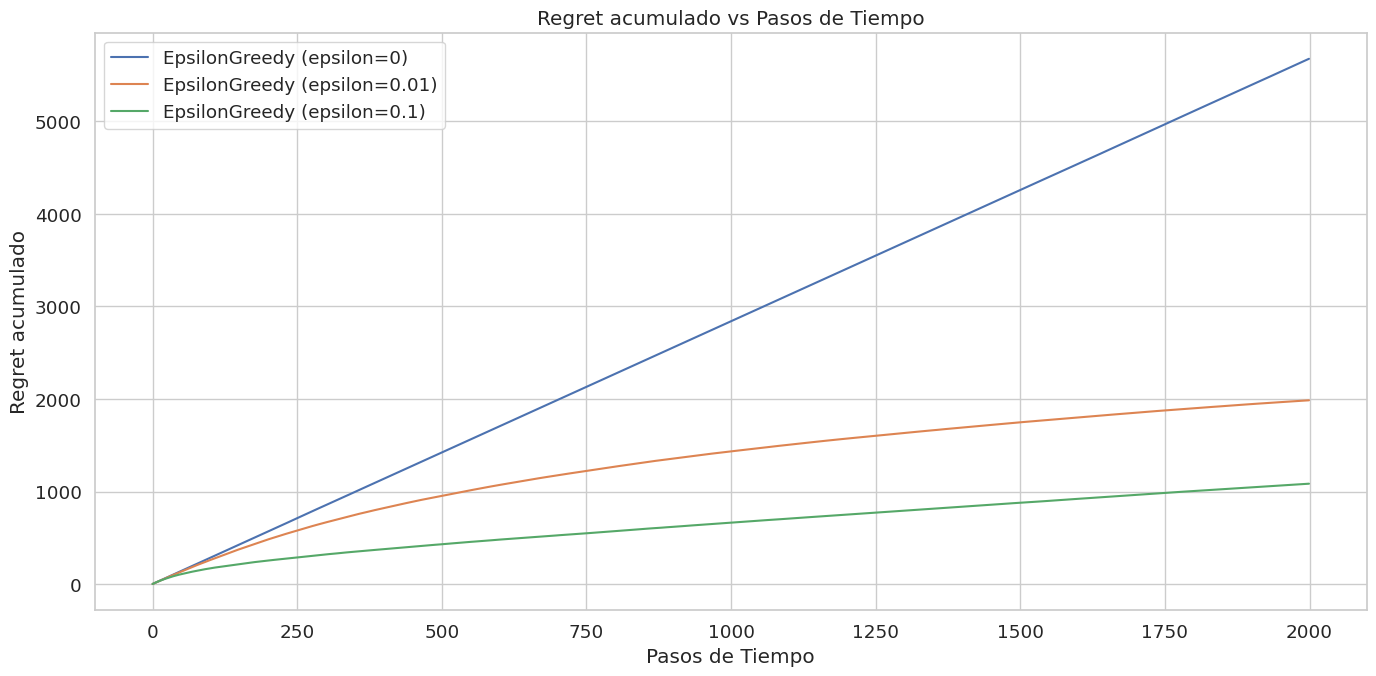


===== k = 100 =====


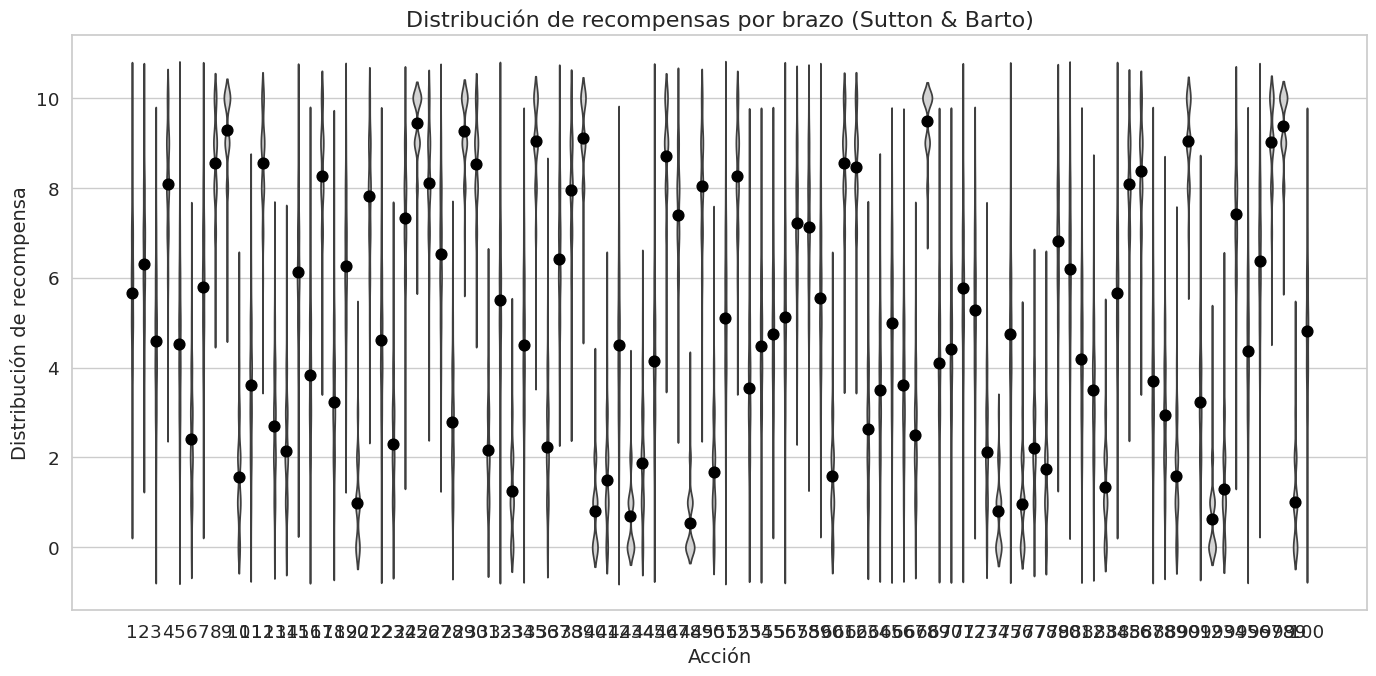

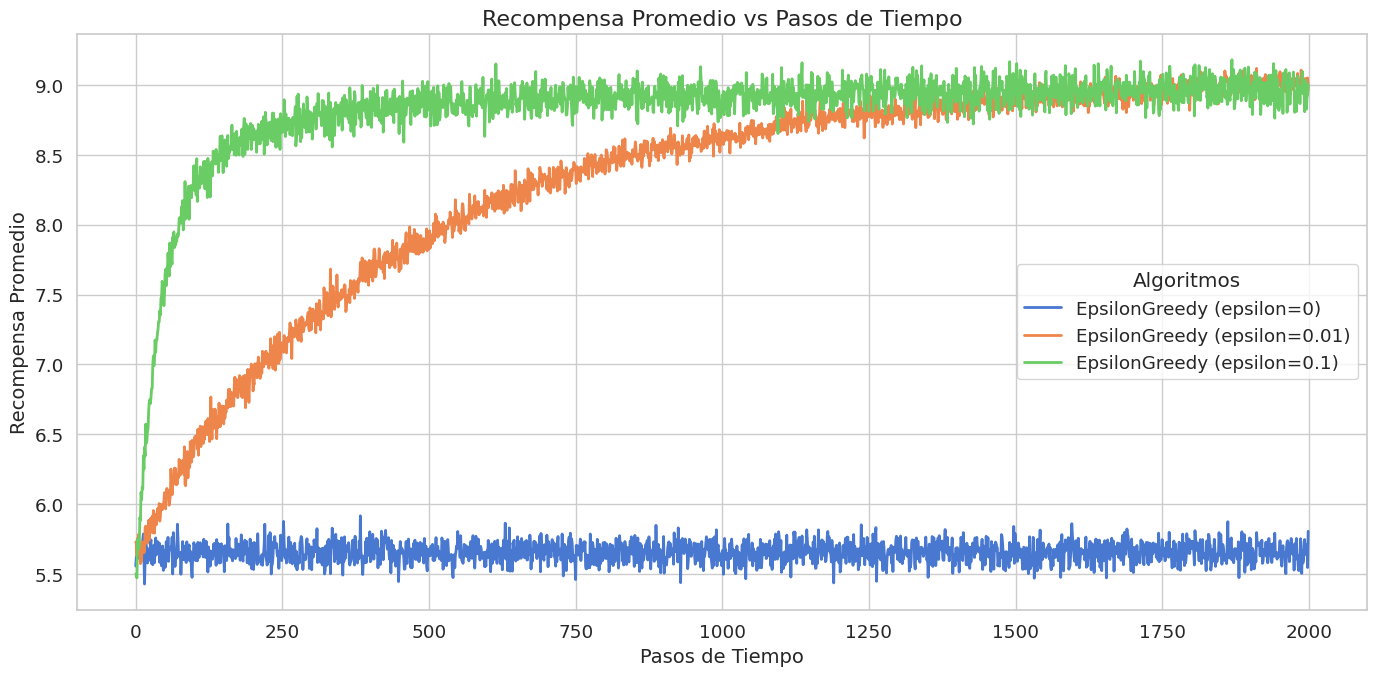

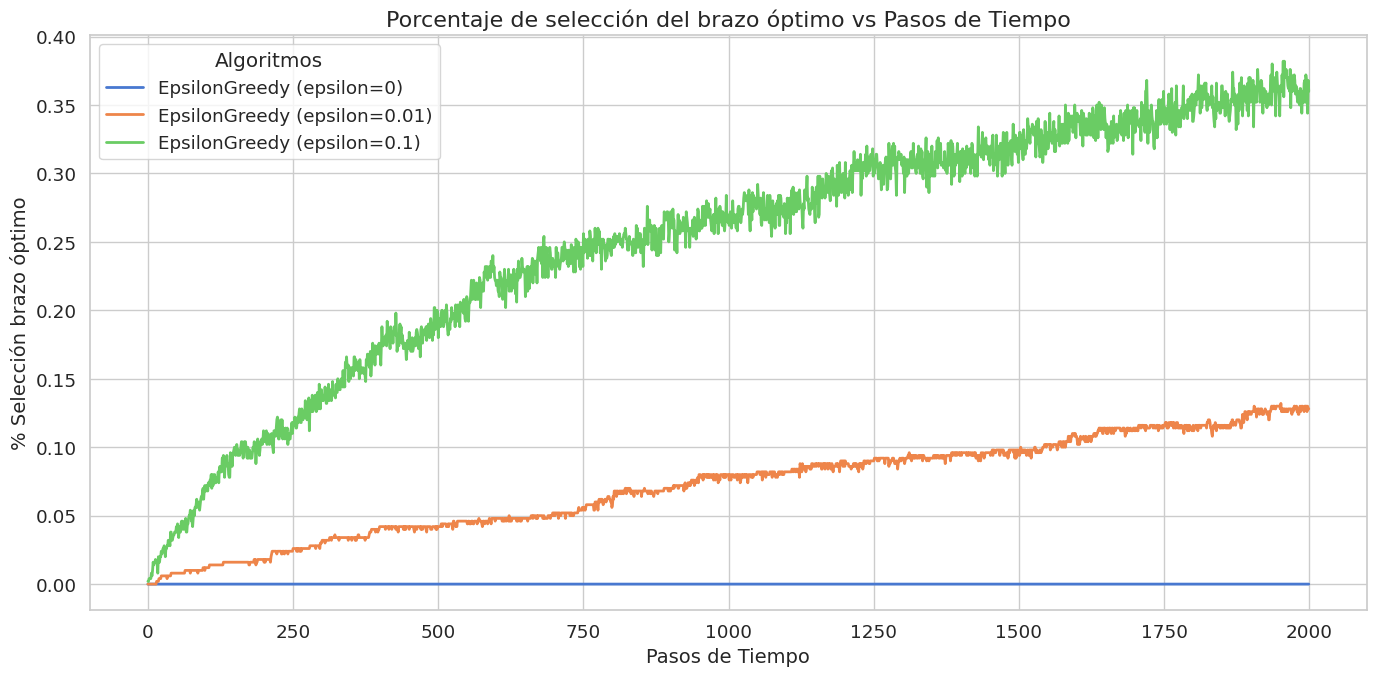

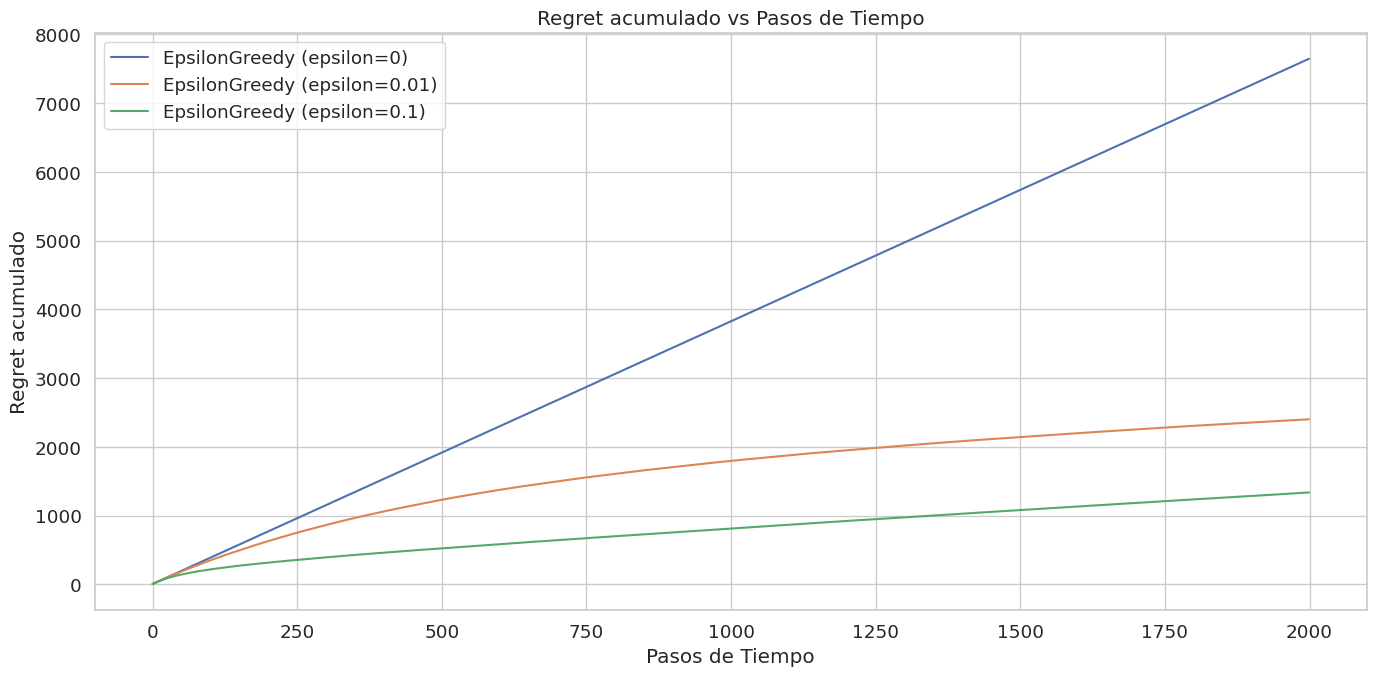

In [36]:



# =====================================================
# FUNCIÓN EXPERIMENTO LOCAL
# =====================================================

def run_experiment_local(bandit, algorithms, steps, runs):

    n_algorithms = len(algorithms)

    rewards = np.zeros((n_algorithms, steps))
    optimal_selections = np.zeros((n_algorithms, steps))
    regret = np.zeros((n_algorithms, steps))

    optimal_arm = bandit.get_optimal_arm()
    optimal_mean = bandit.arms[optimal_arm].get_expected_value()

    for run in range(runs):

        algos = [
            type(algo)(k=bandit.k, epsilon=algo.epsilon)
            for algo in algorithms
        ]

        for t in range(steps):

            for i, algo in enumerate(algos):

                arm_index = algo.select_arm()
                reward = bandit.pull_arm(arm_index)

                algo.update(arm_index, reward)

                rewards[i, t] += reward
                regret[i, t] += optimal_mean - reward

                if arm_index == optimal_arm:
                    optimal_selections[i, t] += 1

    rewards /= runs
    optimal_selections /= runs
    regret /= runs

    cumulative_regret = np.cumsum(regret, axis=1)

    return rewards, optimal_selections, cumulative_regret


# =====================================================
# PARÁMETROS
# =====================================================

steps = 2000
runs = 500

k_values = [10, 20, 100]
epsilon_values = [0, 0.01, 0.1]

n_fixed = 10   # mismo número de ensayos por brazo


# =====================================================
# EXPERIMENTOS
# =====================================================

for k in k_values:

    print(f"\n===== k = {k} =====")

    # Parámetros Binomial
    p_values = np.random.uniform(0.05, 0.95, k)
    arms = [ArmBinomial(n_fixed, p) for p in p_values]

    # 🎻 Sutton & Barto
    plot_reward_distributions(arms)

    bandit = Bandit(arms)

    algorithms = [
        EpsilonGreedy(k=k, epsilon=e)
        for e in epsilon_values
    ]

    rewards, optimal_selections, cumulative_regret = run_experiment_local(
        bandit=bandit,
        algorithms=algorithms,
        steps=steps,
        runs=runs
    )

    # 📈 Recompensa promedio
    plot_average_rewards(steps, rewards, algorithms)

    # 📈 % selección óptima
    plot_optimal_selections(steps, optimal_selections, algorithms)

    # 📉 Regret acumulado
    plot_cumulative_regret(steps, cumulative_regret, algorithms)


**Se analizar el efecto del ruido que faltaba con sigmas 1, 50 y 100:**


===== NORMAL | k = 10 | sigma = 1 =====


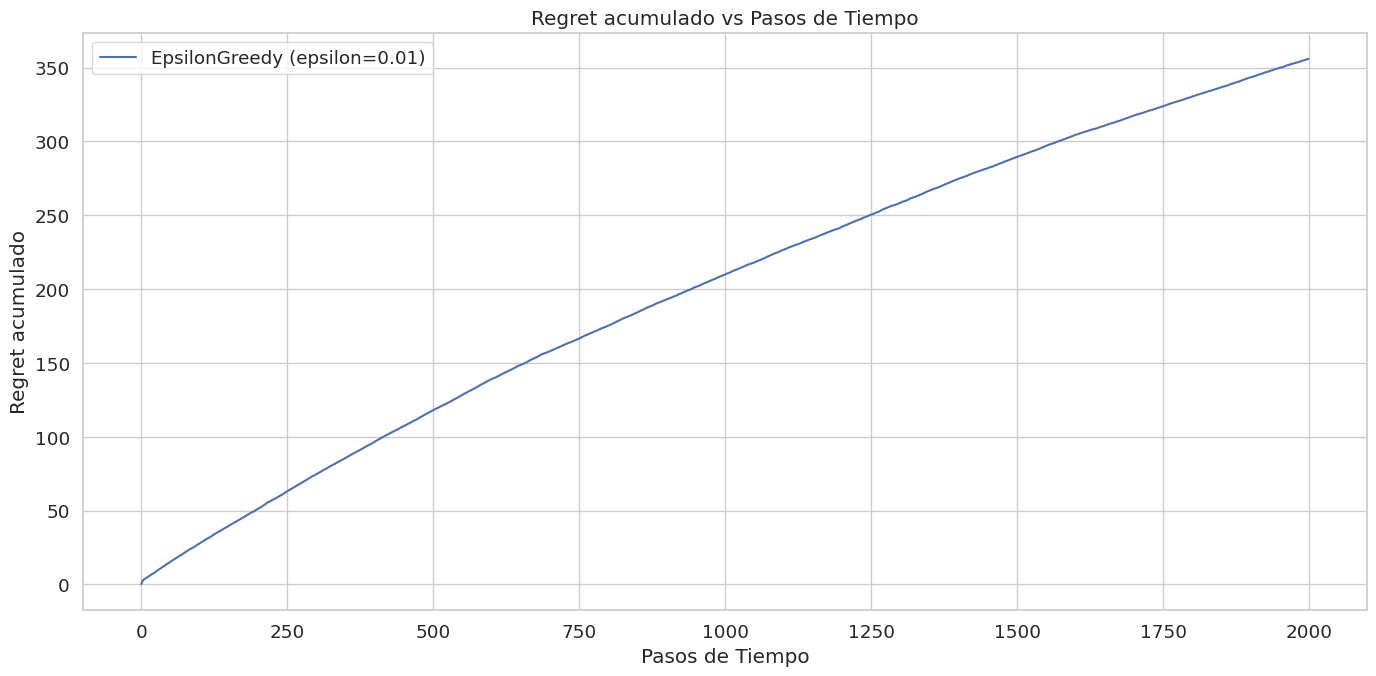


===== NORMAL | k = 10 | sigma = 50 =====


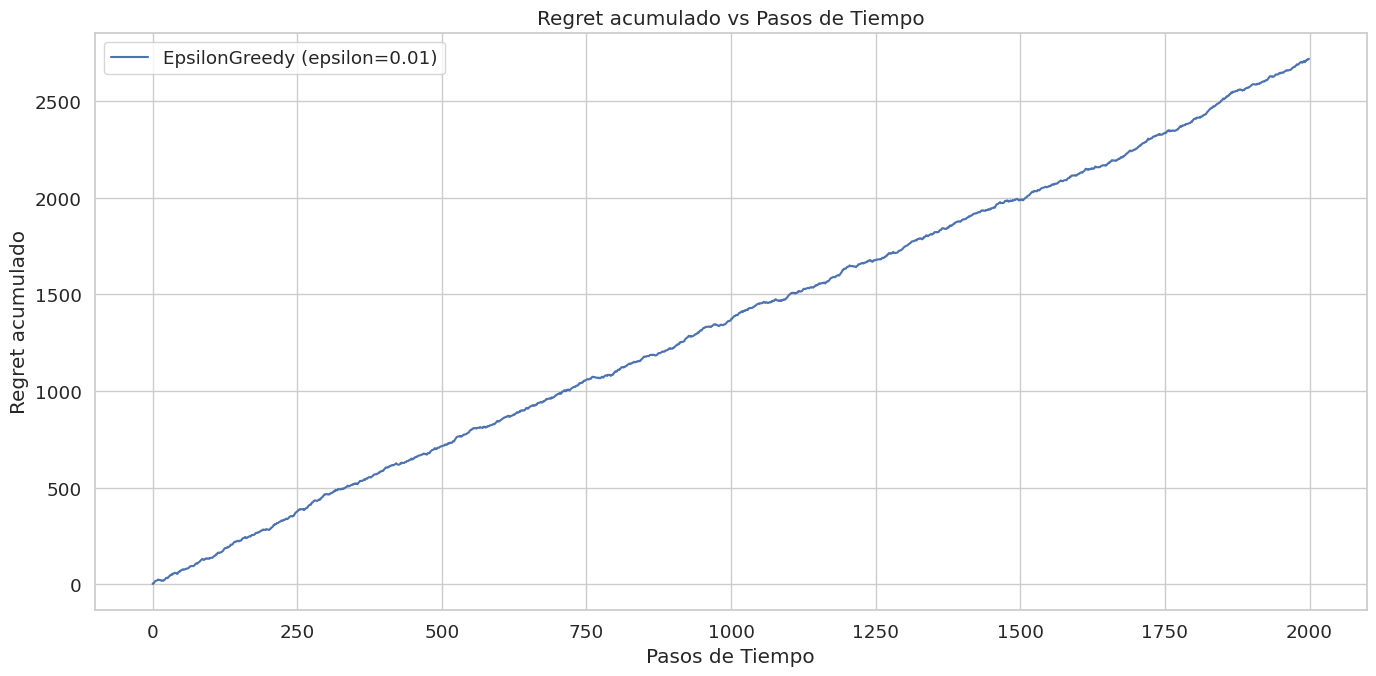


===== NORMAL | k = 10 | sigma = 100 =====


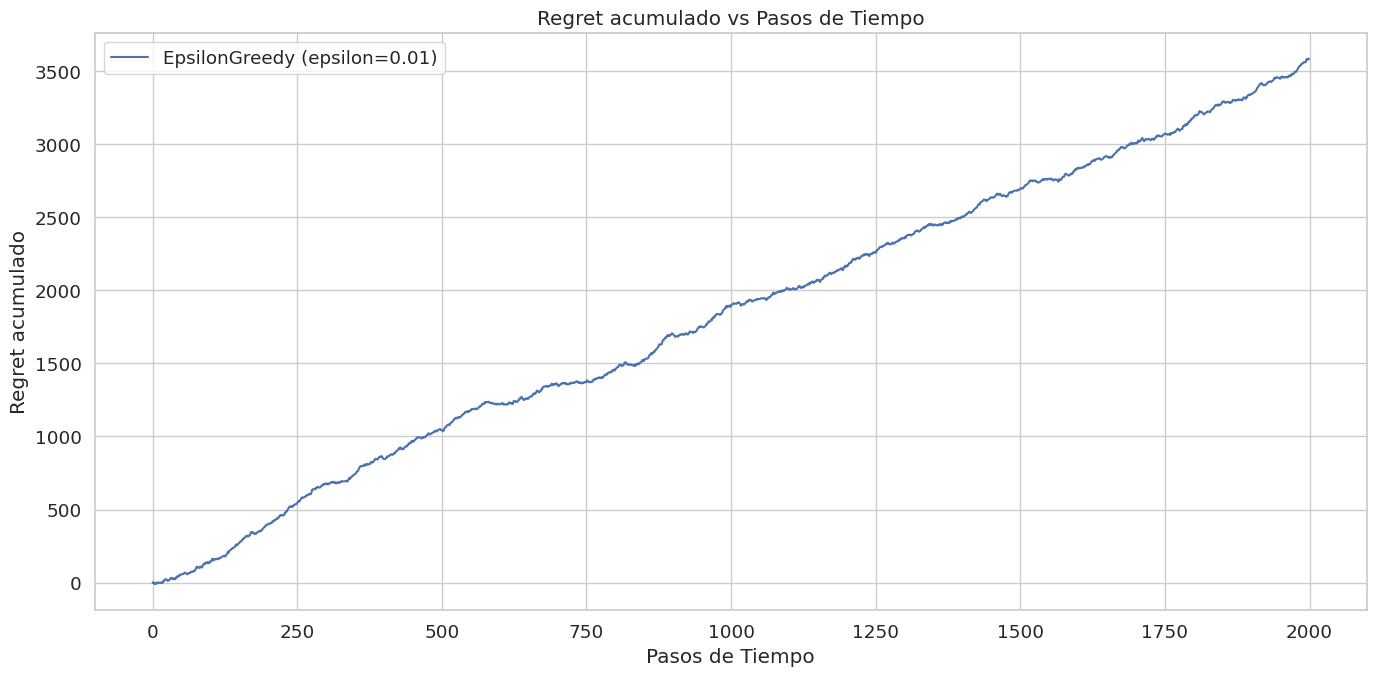

In [37]:
# =====================================================
# ESTUDIO EFECTO DEL RUIDO (σ)
# =====================================================

sigmas = [1, 50, 100]

k = 10
epsilon_values = [0.01]  # fijamos epsilon para observar efecto del ruido

for sigma in sigmas:

    print(f"\n===== NORMAL | k = {k} | sigma = {sigma} =====")

    mu_values = np.random.normal(0, 1, k)
    arms = [ArmNormal(mu, sigma) for mu in mu_values]

    bandit = Bandit(arms)

    algorithms = [
        EpsilonGreedy(k=k, epsilon=e)
        for e in epsilon_values
    ]

    rewards, optimal_selections, cumulative_regret = run_experiment_local(
        bandit=bandit,
        algorithms=algorithms,
        steps=steps,
        runs=runs
    )

    plot_cumulative_regret(steps, cumulative_regret, algorithms)

# Estudio del Algoritmo $\epsilon$-Greedy


## 1. Introducción y Planteamiento
Este documento presenta el análisis exhaustivo del algoritmo **$\epsilon$-greedy** aplicado al problema del bandido de $k$-brazos. Se evalúa la capacidad del algoritmo para equilibrar la **exploración** (probar nuevos brazos) y la **explotación** (usar el mejor brazo conocido) bajo diferentes condiciones de incertidumbre.

**Configuración Experimental:**
* **Pasos ($T$):** 2000
* **Simulaciones (Runs):** 500 (para asegurar significancia estadística).
* **Parámetros de exploración ($\epsilon$):** $0$ (Greedy), $0.01$ (Exploración baja), $0.1$ (Exploración alta).
* **Semilla Aleatoria:** `42` (Garantiza que el experimento sea 100% reproducible).

## 2. Implementación de Bandidos (Brazos)
Siguiendo el enunciado, se han implementado tres distribuciones de recompensa para modelar distintos escenarios:

1.  **Distribución Bernoulli:** Retorna $1$ con probabilidad $p$ y $0$ en caso contrario. Útil para entornos de éxito/fracaso.
2.  **Distribución Binomial $B(n, p)$:** Suma de $n$ ensayos Bernoulli. Proporciona una señal de recompensa más estable.
3.  **Distribución Normal $N(\mu, \sigma^2)$:** Recompensas continuas. Es el escenario más complejo debido al solapamiento de las campanas de Gauss entre diferentes brazos.

## 3. Análisis de Desempeño y Métricas

### A. Recompensa Promedio y % de Selección Óptima
* **$\epsilon = 0.1$:** Es el más rápido en identificar el brazo óptimo, pero su rendimiento se estanca porque nunca deja de explorar (pierde un 10% de recompensa por diseño).
* **$\epsilon = 0.01$:** Aprende más lento, pero a largo plazo (cerca del paso 2000) supera a los demás al enfocarse más en la explotación del brazo ganador.
* **Greedy ($\epsilon = 0$):** Falla frecuentemente al quedar atrapado en brazos subóptimos ("suboptimización prematura").

### B. Regret Acumulado (Métrica Crítica)
El **Regret** representa la pérdida acumulada por no elegir siempre la acción perfecta: $R(T) = \sum_{t=1}^{T} (\mu^* - r_t)$.
* Una curva que se vuelve plana (sublineal) indica que el algoritmo ha "aprendido" y los errores son cada vez menos frecuentes.
* Es la métrica más importante porque cuantifica el **costo total de la ignorancia** del agente.

### C. Impacto del número de brazos ($k$)
Al aumentar $k$ de 10 a 100, el problema se vuelve exponencialmente más difícil. Con 100 brazos, la probabilidad de encontrar el mejor por azar es mínima, haciendo que el valor de $\epsilon = 0.1$ sea indispensable en las fases iniciales de búsqueda.

## 4. Estudio Avanzado: El Efecto del Ruido ($\sigma$)
Se realizó un experimento adicional variando la desviación estándar ($\sigma$) en brazos normales de $1$ a $100$.

**Hallazgos:**
* **Confusión del Agente:** Con $\sigma = 100$, la varianza es tan alta que "oculta" la verdadera media de los brazos. Una sola recompensa azarosa puede desviar completamente la estimación del agente.
* **Crecimiento del Regret:** A mayor ruido, el Regret Acumulado crece de forma casi lineal y con valores mucho más altos. Esto demuestra que $\epsilon$-greedy es muy sensible a la escala de la recompensa y requiere periodos de aprendizaje mucho más largos cuando el entorno es ruidoso.

## 5. Conclusiones Finales

### Respuesta a la pregunta del enunciado:
**¿Cuál de todas las gráficas es la más relevante y por qué?**

La gráfica más relevante es el **Regret Acumulado**.

**Justificación:** Mientras que la recompensa promedio solo nos da una "foto" del momento actual, el Regret Acumulado integra toda la historia del experimento. Nos permite ver de un solo vistazo:
1.  **Eficiencia:** Si la curva es cóncava, el algoritmo es eficiente.
2.  **Costo de Oportunidad:** Cuánta recompensa hemos sacrificado para aprender.
Es la métrica estándar en la literatura científica para comparar algoritmos de toma de decisiones secuencial.

### Conclusión General
El estudio demuestra que no existe un "mejor" $\epsilon$ universal. El valor óptimo depende del horizonte de tiempo y del nivel de ruido del entorno. Para sistemas reales, se recomienda empezar con una exploración alta ($\epsilon=0.1$) y reducirla gradualmente a medida que el agente gana confianza.